# 06g — Inventory Simulation

**Purpose:** Convert forecasts/policies into reorder decisions and simulate business outcomes
on the Fold 2 val window. Section 1 builds the one piece that's still missing — a
`reorder_point`/`order_qty` table for Smooth/Erratic — and merges it with Lumpy/Intermittent
(06f) into a single table covering all SKUs. Section 2 (next) runs `simulate_inventory()`
against it.

**Inputs:**
- `unified_lumpy_intermittent_fold2.parquet` — 06f, Lumpy + Intermittent, already final
- `conformal_residuals_fold2.pkl` — 06e, per-SKU residuals + locked service level(s) for Smooth/Erratic
- `tweedie_optimized_fold2.txt` + `features_train_v2.parquet` — 06d/04b, to regenerate point forecasts (see gap note below)
- `sku_regimes_fold2.parquet` — 06c, routing + regime labels

**Outputs:**
- `final_reorder_params_fold2.parquet` — all ~30,490 SKUs, one schema, ready for Section 2

**Two gaps vs. the plan spec, both handled below:**
1. `new_plan.md`'s Pre-flight #1 assumes `tweedie_optimized_predictions_fold2.parquet` exists
   as an input. It doesn't — 06e's save cell (Section 5) persisted `sku_residuals` and run
   metadata only, never the per-row `yhat` frame it built in memory. Point forecasts are
   regenerated below using 06e Section 1's exact logic, with a row-count sanity check against
   06e's own residual counts to confirm the regenerated population matches what the residuals
   were calibrated against.
2. **Service level is regime-specific, not one locked value.** 06e Section 4 (cell 8) picks a
   *different* service level for Smooth vs. Erratic via an elbow-detection heuristic on
   interval width — `conformal['default_service_level']` is a dict (`{'smooth': 'qXX',
   'erratic': 'qXX'}`), not the single flat 0.80 that Lumpy/Intermittent locked to. The first
   draft of this notebook assumed a scalar and crashed on it. Fixed below by threading the
   per-regime level through the loop, and by adding an explicit `service_level` column to the
   final schema (0.80 for Lumpy/Intermittent, per-regime for Smooth/Erratic) so Section 5 can
   report it honestly instead of implying one level applies everywhere.

---

## Section 1 — Reorder Parameter Computation (Smooth/Erratic) + Three-Way Merge


In [1]:
# ── Setup — load 06e's conformal output, regenerate the point forecasts it never saved ──
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

PROCESSED_DIR    = '../data/processed'
CALIBRATION_DIR  = f'{PROCESSED_DIR}/calibration'
SEGMENTATION_DIR = f'{PROCESSED_DIR}/segmentation'
MODELS_DIR       = f'{PROCESSED_DIR}/models'
PREDICTIONS_DIR  = f'{PROCESSED_DIR}/predictions'

LEAD_TIME_DAYS = 7   # same lead time 06f Section 6/7 locked for Lumpy + Intermittent

with open(f'{CALIBRATION_DIR}/conformal_residuals_fold2.pkl', 'rb') as f:
    conformal = pickle.load(f)

sku_residuals = conformal['sku_residuals']
# NOT a single float -- 06e Section 4 picks a service level PER REGIME (elbow-detection on
# interval width), e.g. {'smooth': 'q80', 'erratic': 'q90'}. Converted to a fraction below.
SERVICE_LEVEL_BY_REGIME = conformal['default_service_level']
RESIDUAL_UNIT = conformal['residual_unit']
WINNER_MODEL  = conformal['winner_model']

def service_level_frac(regime):
    """'q80' -> 0.80. Falls back to 0.80 if a regime is missing from the dict."""
    label = SERVICE_LEVEL_BY_REGIME.get(regime, 'q80')
    return int(label[1:]) / 100

print(f'Loaded conformal residuals for {len(sku_residuals):,} SKUs.')
print(f'Residual unit: {RESIDUAL_UNIT}')
print(f'Locked service levels by regime: {SERVICE_LEVEL_BY_REGIME}')

# SANITY CHECK, not a blocker: 06e Section 1 filtered to Tweedie-routed SKUs only (~9,196
# expected). If len(sku_residuals) above is closer to the FULL SKU population (~30,490),
# 06e's scope may have changed since last reviewed -- worth confirming on your end. The loop
# below only ever iterates `tweedie_skus` regardless, so this can't corrupt this notebook's
# output, but it's a signal something upstream may be worth a second look.

# Which 06d experiments trained on a 7-day-forward-sum target vs. next-day -- same check
# 06e Section 1 used, kept here so the branch below can't silently drift from what the
# residuals were actually calibrated against.
SEVEN_DAY_TARGET_EXPERIMENTS = {'experiment_a', 'experiment_c'}
TARGET_IS_7DAY = WINNER_MODEL in SEVEN_DAY_TARGET_EXPERIMENTS
assert (RESIDUAL_UNIT == 'expected demand, rolling next-7-days') == TARGET_IS_7DAY, (
    'Winner model / residual unit mismatch vs. 06e -- regenerating yhat below would use the '
    'wrong native-space branch. Stop and check 06e Section 1 before proceeding.'
)

FOLD2_VAL_START = '2014-02-01'
CALIBRATION_END = '2014-08-31'   # same calibration window the residuals were built on

model = lgb.Booster(model_file=f'{MODELS_DIR}/tweedie_optimized_fold2.txt')
sku_regimes = pd.read_parquet(f'{SEGMENTATION_DIR}/sku_regimes_fold2.parquet')
tweedie_skus = set(sku_regimes.loc[sku_regimes['routing'] == 'tweedie', 'id'])
regime_map = sku_regimes.set_index('id')['regime'].to_dict()

print(f'Tweedie-routed SKUs (Smooth+Erratic, from 06c routing): {len(tweedie_skus):,}')

train_full = pd.read_parquet(f'{PROCESSED_DIR}/features/features_train_v2.parquet')
train_full['date'] = pd.to_datetime(train_full['date'])
with open(f'{PROCESSED_DIR}/features/feature_cols_v2.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

mask_se    = train_full['id'].isin(tweedie_skus)
mask_calib = (train_full['date'] >= FOLD2_VAL_START) & (train_full['date'] <= CALIBRATION_END)
calib_se = train_full[mask_se & mask_calib].sort_values(['id', 'date']).copy()
calib_se['yhat'] = np.maximum(model.predict(calib_se[feature_cols].values), 0)

print(f"Regenerated yhat for {calib_se['id'].nunique():,} Smooth/Erratic SKUs "
      f'over the calibration window ({len(calib_se):,} rows).')

# Sanity check: regenerated population should match 06e's residual counts row-for-row for
# the Tweedie-routed SKUs specifically -- same window, same SKUs, same model. A mismatch
# here means these yhat values aren't the same population the residuals were calibrated
# against, and nothing below can be trusted.
residual_counts = pd.Series({k: len(v) for k, v in sku_residuals.items() if k in tweedie_skus})
row_counts = calib_se.groupby('id', observed=True).size()
common = residual_counts.index.intersection(row_counts.index)
mismatch = (residual_counts.loc[common] != row_counts.loc[common]).sum()
print(f'Tweedie SKUs with mismatched row/residual counts vs. 06e: {mismatch:,} / {len(common):,}')

missing_from_calib = sorted(tweedie_skus - set(row_counts.index))
print(f'Tweedie-routed SKUs with zero rows in the calibration window: {len(missing_from_calib):,}')
if missing_from_calib:
    print('  These have no history to forecast from -- caught by the NaN-forecast guard in the')
    print('  next cell (empty-group mean -> NaN), not excluded via a point_forecast.index check.')

# BUG FOUND + FIXED: 'id' is a categorical dtype, so groupby('id') without observed=True keeps
# every one of the full 30,490 SKU categories in its output index -- including the ~21,271 that
# have zero rows in calib_se after filtering. That silently broke the two checks above (both
# were structurally guaranteed to read '0'/'all-present' regardless of the real data) and meant
# the 'excluded here' comment on missing_from_calib was never actually true -- those SKUs fell
# through to point_forecast in the next cell instead. observed=True above fixes row_counts here;
# the same fix is applied to point_forecast in the next cell.


Loaded conformal residuals for 30,490 SKUs.
Residual unit: expected demand, next-day
Locked service levels by regime: {'smooth': 'q80', 'erratic': 'q80'}
Tweedie-routed SKUs (Smooth+Erratic, from 06c routing): 9,219
Regenerated yhat for 9,171 Smooth/Erratic SKUs over the calibration window (1,806,148 rows).
Tweedie SKUs with mismatched row/residual counts vs. 06e: 0 / 9,171
Tweedie-routed SKUs with zero rows in the calibration window: 48
  These have no history to forecast from -- caught by the NaN-forecast guard in the
  next cell (empty-group mean -> NaN), not excluded via a point_forecast.index check.


In [2]:
# ── compute_reorder_params — Smooth/Erratic only (Lumpy/Intermittent read directly in the ──
# merge cell below, per Pre-flight #1; nothing here touches those two regimes)
MIN_RESIDUALS_PER_SKU = 5   # same floor 06e Section 2 used for a stable per-SKU quantile

point_forecast = calib_se.groupby('id', observed=True)['yhat'].mean()   # "typical demand," same framing as
                                                          # Lumpy's avg_weekly / Intermittent's
                                                          # mean_lead_time_demand -- a single
                                                          # static value per SKU, not the most
                                                          # recent day's forecast (Pre-flight #3
                                                          # needs a fixed value, not a moving one)

# Pooled fallback for SKUs with too few calibration residuals for their own stable quantile.
# Built PER REGIME now, not globally pooled -- Smooth and Erratic use different service
# levels, so a single global pooled quantile would apply the wrong level to half the fallback.
pooled_residuals_by_regime = {}
for regime in ('smooth', 'erratic'):
    ids_in_regime = {sid for sid, r in regime_map.items() if r == regime}
    pooled = np.concatenate([
        np.asarray(v) for sid, v in sku_residuals.items() if sid in ids_in_regime
    ]) if ids_in_regime else np.array([0.0])
    pooled_residuals_by_regime[regime] = pooled

rows = []
n_negative_q80 = 0
n_nan_forecast = 0
n_zero_history_excluded = 0
nan_forecast_ids = []
for sku_id in sorted(tweedie_skus):
    if sku_id not in point_forecast.index:
        # With observed=True fixed above, this now actually fires for the zero-history
        # cohort instead of being a dead branch -- explicitly excluded here, not routed
        # through the NaN-forecast guard below.
        n_zero_history_excluded += 1
        continue

    regime = regime_map[sku_id]
    sl = service_level_frac(regime)   # regime-specific, not a flat 0.80

    pf_native = point_forecast[sku_id]
    residuals = sku_residuals.get(sku_id, [])
    low_conf  = len(residuals) < MIN_RESIDUALS_PER_SKU
    if low_conf:
        resid_q = np.percentile(pooled_residuals_by_regime.get(regime, [0.0]), sl * 100)
    else:
        resid_q = np.percentile(residuals, sl * 100)
    if resid_q < 0:
        n_negative_q80 += 1
    resid_q = max(resid_q, 0.0)   # a SKU that mostly over-forecasts gets no negative "safety
                                   # debt" -- floored the same way Intermittent's reactive-only
                                   # cohort was in 06f, not left as-is

    # NOTE: residual = target - yhat already, so `resid_q` IS the interval half-width
    # (equivalent to the plan's `q_upper - point_forecast`) -- no second subtraction needed.
    if TARGET_IS_7DAY:
        # Model already predicts a native 7-day-forward sum -- no daily->lead-time scaling.
        expected_lead_time_demand = pf_native
        safety_stock = resid_q
    else:
        # Model predicts next-day units -- scaling to the 7-day lead time via sqrt(7).
        # UNVALIDATED (Pre-flight #4): assumes i.i.d. daily forecast errors. 06f Section 6
        # found the opposite for Intermittent (real demand clusters in time, ~2.9x more
        # lead-time variance than an independent-day model implies). Smooth/Erratic demand is
        # more regular and may hold up better, but that hasn't been checked with the same
        # rolling-origin coverage test yet -- do not treat these reorder points as trustworthy
        # until that runs.
        expected_lead_time_demand = pf_native * LEAD_TIME_DAYS
        safety_stock = resid_q * np.sqrt(LEAD_TIME_DAYS)

    # GUARD: Python's built-in max() does NOT floor NaN -- max(nan, 1.0) returns nan, because
    # every comparison against nan is False. If the point forecast came out NaN/inf (e.g. a
    # SKU with too little lag-feature history in the calibration window), silently taking
    # max(nan, 1.0) would let a NaN slip into order_qty and fail the assert below with no
    # visibility into which SKU or why. Caught explicitly instead: treated as low-confidence/
    # fallback (same as the zero-history cohort), not guessed at.
    if not (np.isfinite(expected_lead_time_demand) and np.isfinite(safety_stock)):
        n_nan_forecast += 1
        nan_forecast_ids.append(sku_id)
        low_conf = True
        fallback_required = True
        expected_lead_time_demand = 0.0
        safety_stock = 0.0
        reorder_point = 0.0
        order_qty = 1.0
    else:
        fallback_required = low_conf
        reorder_point = expected_lead_time_demand + safety_stock
        order_qty = max(expected_lead_time_demand, 1.0)   # never order zero -- same floor logic as 06f

    rows.append({
        'id':                        sku_id,
        'regime':                    regime,
        'method':                    'conformal_tweedie',
        'expected_lead_time_demand': expected_lead_time_demand,
        'reorder_point':             reorder_point,
        'safety_buffer':             safety_stock,
        'order_qty':                 order_qty,
        'low_confidence':            low_conf,
        'fallback_required':         fallback_required,
        'sqrt_scaling_unvalidated':  not TARGET_IS_7DAY,
        'service_level':             sl,
    })

smooth_erratic_unified = pd.DataFrame(rows)

print(f'Zero-history SKUs excluded (no rows in calibration window): {n_zero_history_excluded:,}')
print(f'SKUs with NaN/inf point forecast (guarded, forced to fallback): {n_nan_forecast:,}')
if nan_forecast_ids:
    print(f'  Sample IDs: {nan_forecast_ids[:10]}')
    print('  Worth checking whether these share a cause (e.g. launched too recently for full')
    print('  lag-feature history in the calibration window) before trusting the fallback value.')

assert smooth_erratic_unified['order_qty'].notna().all() and (smooth_erratic_unified['order_qty'] > 0).all(), (
    'BUG: some Smooth/Erratic SKU has order_qty <= 0 -- would never reorder in simulation.'
)

print(f'Smooth/Erratic reorder table: {len(smooth_erratic_unified):,} SKUs.')
print(f'Low-confidence (<{MIN_RESIDUALS_PER_SKU} calib residuals OR NaN forecast): '
      f"{smooth_erratic_unified['low_confidence'].sum():,}")
print(f'SKUs where the raw q_level residual was negative before flooring: {n_negative_q80:,} '
      f'(over-forecasting cohort -- reactive-only, same shape as Intermittent\'s cohort in 06f)')
print()
print(smooth_erratic_unified.groupby('regime')[
    ['expected_lead_time_demand', 'reorder_point', 'safety_buffer', 'order_qty', 'service_level']
].describe().round(2))


Zero-history SKUs excluded (no rows in calibration window): 48
SKUs with NaN/inf point forecast (guarded, forced to fallback): 0
Smooth/Erratic reorder table: 9,171 SKUs.
Low-confidence (<5 calib residuals OR NaN forecast): 0
SKUs where the raw q_level residual was negative before flooring: 655 (over-forecasting cohort -- reactive-only, same shape as Intermittent's cohort in 06f)

        expected_lead_time_demand                                         \
                            count   mean    std   min   25%   50%    75%   
regime                                                                     
erratic                     827.0  17.32  29.00  0.94  4.04  7.60  17.03   
smooth                     8344.0  14.89  29.37  0.68  3.77  6.79  14.21   

                reorder_point         ... order_qty         service_level  \
            max         count   mean  ...       75%     max         count   
regime                                ...                                   
erra

In [3]:
# ── Cadence check + three-way merge ──────────────────────────────────────────────────────
# Mirrors 06f Section 7's cadence assert before it concatenated Lumpy + Intermittent --
# confirms Smooth/Erratic's regenerated 7-day lead-time figures and Lumpy/Intermittent's
# weekly figures are actually on the same clock before treating them as comparable.
assert LEAD_TIME_DAYS == 7, (
    'Smooth/Erratic reorder points above assume a 7-day lead time. Lumpy (06f Section 4, '
    'lead_time_weeks=1) and Intermittent (06f Section 6, LEAD_TIME_DAYS=7) both assumed the '
    'same -- if LEAD_TIME_DAYS changes here, the three regimes are no longer on the same '
    'clock and cannot be merged as-is.'
)

lumpy_intermittent = pd.read_parquet(f'{PREDICTIONS_DIR}/unified_lumpy_intermittent_fold2.parquet')
lumpy_intermittent['sqrt_scaling_unvalidated'] = False   # policy / block-bootstrap methods --
                                                          # no i.i.d.-daily-error assumption involved
lumpy_intermittent['service_level'] = 0.80               # locked flat value, per 06f Section 6

# ── PATCH: order_qty for Intermittent currently = z_final (mean single-event size) --
# not lead-time scaled like Smooth/Erratic and Lumpy. Redefine as expected lead-time
# demand (already computed by 06f's block bootstrap, sitting in `expected_lead_time_demand`),
# floored at z_final so we never order less than one typical historical demand event.
is_intermittent = lumpy_intermittent['regime'] == 'intermittent'
z_final_floor = lumpy_intermittent.loc[is_intermittent, 'order_qty'].copy()
lumpy_intermittent.loc[is_intermittent, 'order_qty'] = np.maximum(
    lumpy_intermittent.loc[is_intermittent, 'expected_lead_time_demand'],
    z_final_floor
).clip(lower=1.0)  # mirrors 06f Section 6's MIN_ORDER_ACTIVE_INTERMITTENT floor

print(f"Intermittent order_qty repatch: {is_intermittent.sum():,} SKUs, "
      f"median {z_final_floor.median():.2f} -> "
      f"{lumpy_intermittent.loc[is_intermittent, 'order_qty'].median():.2f}")

final_reorder_params = pd.concat([lumpy_intermittent, smooth_erratic_unified], ignore_index=True)

expected_total = sku_regimes['id'].nunique()
actual_total   = len(final_reorder_params)
print(f'Merged table: {actual_total:,} SKUs vs. {expected_total:,} in 06c\'s full routing '
      f'({expected_total - actual_total:,} short -- should equal the zero-calibration-history '
      f'count printed above, if any).')

assert final_reorder_params['order_qty'].notna().all() and (final_reorder_params['order_qty'] > 0).all(), (
    'order_qty must be populated and positive for every SKU across all three regimes before '
    'Section 2 can run simulate_inventory().'
)

print()
print(final_reorder_params['regime'].value_counts())
print()
print('Service level in effect, by regime:')
print(final_reorder_params.groupby('regime')['service_level'].agg(['min', 'max', 'mean']).round(2))
print()
print(f'Low-confidence / fallback SKUs by regime (Smooth/Erratic only -- Lumpy/Intermittent '
      f'have their own flags from 06f):')
print(final_reorder_params.groupby('regime')[['low_confidence', 'fallback_required']].mean().round(3) * 100)

os.makedirs(PREDICTIONS_DIR, exist_ok=True)
final_reorder_params.to_parquet(f'{PREDICTIONS_DIR}/final_reorder_params_fold2.parquet')
print(f'\n✓ final_reorder_params_fold2.parquet saved ({actual_total:,} SKUs, all regimes).')
print('REMINDER: Smooth/Erratic reorder points carry an unvalidated sqrt(lead_time) daily-error')
print('assumption (Pre-flight #4, sqrt_scaling_unvalidated=True) -- run the rolling-origin')
print('coverage check before Section 2 trusts them in the simulation.')


Intermittent order_qty repatch: 14,268 SKUs, median 1.36 -> 3.04
Merged table: 30,442 SKUs vs. 30,490 in 06c's full routing (48 short -- should equal the zero-calibration-history count printed above, if any).

regime
intermittent    14268
smooth           8344
lumpy            7003
erratic           827
Name: count, dtype: int64

Service level in effect, by regime:
              min  max  mean
regime                      
erratic       0.8  0.8   0.8
intermittent  0.8  0.8   0.8
lumpy         0.8  0.8   0.8
smooth        0.8  0.8   0.8

Low-confidence / fallback SKUs by regime (Smooth/Erratic only -- Lumpy/Intermittent have their own flags from 06f):
              low_confidence  fallback_required
regime                                         
erratic                  0.0                0.0
intermittent             0.0                0.0
lumpy                   59.8               59.8
smooth                   0.0                0.0

✓ final_reorder_params_fold2.parquet saved (30,442 S

#### Section 1 Findings — Reorder Parameter Computation + Three-Way Merge

**Bug fixed:** `id` is a categorical column; `groupby('id')` without `observed=True` was silently spanning all 30,490 SKU categories instead of the filtered subset, making two sanity checks structurally unable to fail. Fixed with `observed=True`; diagnostic cell confirms it (`row_counts entries` now equals `nunique`, both 9,171).

**Population:** 9,219 Tweedie-routed SKUs (8,389 smooth + 830 erratic) → **48 excluded** (zero calibration-window history) → **9,171 in the final reorder table** (8,344 smooth + 827 erratic). `n_nan_forecast` dropped to **0**, confirming the 48 "NaN forecast" SKUs from the buggy run were this same zero-history cohort, not a separate issue.

**Merge:** 30,442 SKUs total (14,268 intermittent + 8,344 smooth + 7,003 lumpy + 827 erratic) = 30,490 − 48, exactly as predicted.

**Low-confidence/fallback:** 0% for Smooth/Erratic now (the 48 that used to inflate this count are cleanly excluded instead). Lumpy's 59.8% is carried over from 06f, unrelated to this fix.

**Unaffected by the bug, stands as before:** 655 SKUs with negative raw residual quantile (reactive-only cohort), service levels flat at 0.80 across all regimes, `sqrt(lead_time)` scaling for Smooth/Erratic **still unvalidated** (Pre-flight #4 — not resolved here, still a caveat on Section 2's Smooth/Erratic results specifically).

**Output:** `final_reorder_params_fold2.parquet`, 30,442 SKUs, saved.

## Section 2 — Inventory Depletion Simulation

**Purpose:** Simulate week-by-week inventory under the locked reorder policy from Section 1
(`final_reorder_params_fold2.parquet`), against **actual** sales in the Fold 2 val window —
`simulate_inventory()` per `new_plan.md`'s Phase E spec.

**Decisions made explicit here, not defaulted silently (mirrors the Pre-flight discipline from
Section 1):**

1. **Val window:** `2014-02-01` -> `2015-01-31`, the full Fold 2 val period per the plan's
   Section 2 spec ("Feb 2014 -> Jan 2015"). Different from Section 1's `CALIBRATION_END`
   (`2014-08-31`), which was only the conformal calibration sub-window -- this is the full
   held-out year the simulation actually evaluates against.
2. **Reorder quantity is static**, sourced directly from `order_qty` in the unified table for
   all three regimes -- this is Pre-flight #3's resolution (fixed-quantity policy, not
   order-up-to-S), already locked in Section 1's schema.
3. **`initial_inventory` was never specified in the plan** -- resolved here as
   `reorder_point + order_qty`, i.e. simulate starting from a freshly-stocked shelf (holding the
   reorder point's buffer plus one full incoming replenishment already on the shelf). This is a
   real assumption with real consequences for early-simulation stockout rates and needs to be
   named, the same way order_qty's definition was in Section 1 -- not left as an implicit
   default inside the loop.
4. **Lead time:** `LEAD_TIME_WEEKS = 1`, consistent with the `LEAD_TIME_DAYS == 7` assert
   already locked across all three regimes in Section 1's cadence check.
5. **This section runs the simulation once, at each SKU's already-locked service level**
   (q80 flat for Lumpy/Intermittent, per-regime q80 for Smooth/Erratic) -- not yet the
   multi-service-level sweep (`new_plan.md` Section 3) or the cost tradeoff curve (Section 4).
   Those come after this section's output is confirmed correct.

In [4]:
# ── 06g Section 2: Inventory Depletion Simulation ────────────────────────────────────────
RAW_DIR = '../data/raw'
SIM_VAL_START = '2014-02-01'
SIM_VAL_END   = '2015-01-31'   # Fold 2 val window, full year -- see Section 2 intro, decision 1
LEAD_TIME_WEEKS = 1            # matches LEAD_TIME_DAYS == 7 locked in Section 1's cadence check

calendar_df = pd.read_csv(f'{RAW_DIR}/calendar.csv')
calendar_df['date'] = pd.to_datetime(calendar_df['date'])
day_to_date = calendar_df.set_index('d')['date'].to_dict()

raw_sales = pd.read_csv(f'{RAW_DIR}/sales_train_validation.csv')
day_cols_all = [c for c in raw_sales.columns if c.startswith('d_')]

val_day_cols = [
    d for d in day_cols_all
    if d in day_to_date and SIM_VAL_START <= str(day_to_date[d].date()) <= SIM_VAL_END
]
val_dates = pd.to_datetime([day_to_date[d] for d in val_day_cols])
print(f'Fold 2 val window for simulation: {val_dates.min().date()} -> {val_dates.max().date()} '
      f'({len(val_day_cols)} days)')

final_reorder_params = pd.read_parquet(f'{PREDICTIONS_DIR}/final_reorder_params_fold2.parquet')
sim_ids = set(final_reorder_params['id'])
print(f'SKUs entering simulation from Section 1: {len(sim_ids):,}')

# ── Build weekly actual-demand matrix (id x week) directly from raw sales, same source 06f
# used for its own raw zero-fraction sanity check -- avoids reloading the 440MB feature parquet
# for data this simple. ────────────────────────────────────────────────────────────────────
sales_val = raw_sales[raw_sales['id'].isin(sim_ids)].set_index('id')[val_day_cols]
missing_sales_ids = sorted(sim_ids - set(sales_val.index))
print(f'SKUs with no matching row in raw sales file: {len(missing_sales_ids):,}')
if missing_sales_ids:
    print(f'  Sample: {missing_sales_ids[:5]} -- excluded from simulation, see Findings.')

sales_val_t = sales_val.T
sales_val_t.index = val_dates
weekly_actuals = sales_val_t.resample('W').sum().T   # id (rows) x calendar week (cols)
print(f'Weekly actual-demand matrix: {weekly_actuals.shape[0]:,} SKUs x {weekly_actuals.shape[1]} weeks')


def simulate_inventory(actual_weekly_demand: np.ndarray,
                        reorder_point: float,
                        reorder_qty: float,
                        initial_inventory: float,
                        lead_time_weeks: int) -> dict:
    inventory = initial_inventory
    stockout_weeks = 0
    units_short = 0.0   # NEW: cumulative unfulfilled demand -- feeds Section 4's cost model
    inventory_history = []
    pending_order = 0
    weeks_until_arrival = 0

    for week, demand in enumerate(actual_weekly_demand):
        if weeks_until_arrival == 0 and pending_order > 0:
            inventory += pending_order
            pending_order = 0

        fulfilled = min(inventory, demand)
        if demand > inventory:
            stockout_weeks += 1
            units_short += (demand - inventory)   # NEW
        inventory -= fulfilled

        if inventory <= reorder_point and pending_order == 0:
            pending_order = reorder_qty
            weeks_until_arrival = lead_time_weeks

        inventory_history.append(inventory)
        if weeks_until_arrival > 0:
            weeks_until_arrival -= 1

    return {
        'stockout_rate': stockout_weeks / len(actual_weekly_demand),
        'avg_inventory': np.mean(inventory_history),
        'fill_rate': 1 - stockout_weeks / len(actual_weekly_demand),
        'units_short': units_short,   # NEW
        'inventory_history': inventory_history,
    }


sim_rows = []
skipped_no_sales = 0
for row in final_reorder_params.itertuples(index=False):
    sku_id = row.id
    if sku_id not in weekly_actuals.index:
        skipped_no_sales += 1
        continue

    demand = weekly_actuals.loc[sku_id].values
    # Decision 3 (Section 2 intro): freshly-stocked-shelf starting assumption, made explicit
    # rather than an implicit zero or an implicit reorder_point-only default.
    initial_inventory = row.reorder_point + row.order_qty

    result = simulate_inventory(
        actual_weekly_demand=demand,
        reorder_point=row.reorder_point,
        reorder_qty=row.order_qty,
        initial_inventory=initial_inventory,
        lead_time_weeks=LEAD_TIME_WEEKS,
    )
    sim_rows.append({
        'id': sku_id,
        'regime': row.regime,
        'service_level': row.service_level,
        'stockout_rate': result['stockout_rate'],
        'avg_inventory': result['avg_inventory'],
        'fill_rate': result['fill_rate'],
    })

assert skipped_no_sales == len(missing_sales_ids), (
    'Loop-level skip count disagrees with the missing_sales_ids check above -- investigate '
    'before trusting simulation_results.'
)

simulation_results = pd.DataFrame(sim_rows)
print()
print(f'Simulated {len(simulation_results):,} SKUs '
      f'({skipped_no_sales:,} skipped -- no raw sales row, see Findings).')
print()
print('── Simulation results by regime, at each regime\'s locked service level ──')
print(simulation_results.groupby('regime')[['stockout_rate', 'avg_inventory', 'fill_rate']]
      .describe().round(3))

os.makedirs(PREDICTIONS_DIR, exist_ok=True)
simulation_results.to_parquet(f'{PREDICTIONS_DIR}/simulation_results_fold2.parquet')
print(f'\n✓ simulation_results_fold2.parquet saved ({len(simulation_results):,} SKUs).')

Fold 2 val window for simulation: 2014-02-01 -> 2015-01-31 (365 days)
SKUs entering simulation from Section 1: 30,442
SKUs with no matching row in raw sales file: 0
Weekly actual-demand matrix: 30,442 SKUs x 53 weeks

Simulated 30,442 SKUs (0 skipped -- no raw sales row, see Findings).

── Simulation results by regime, at each regime's locked service level ──
             stockout_rate                                                 \
                     count   mean    std  min    25%    50%    75%    max   
regime                                                                      
erratic              827.0  0.219  0.118  0.0  0.132  0.208  0.283  0.660   
intermittent       14268.0  0.241  0.237  0.0  0.057  0.170  0.377  1.000   
lumpy               7003.0  0.168  0.244  0.0  0.000  0.038  0.245  1.000   
smooth              8344.0  0.219  0.126  0.0  0.132  0.189  0.283  0.698   

             avg_inventory          ...                   fill_rate         \
                    

In [5]:
# ── Section 2 Sensitivity Check: is the ~2-4pp shortfall a shared warm-up artifact? ──────
# Decision 3 (Section 2 intro) started every SKU at reorder_point + order_qty (freshly-
# stocked shelf). Testing the more conservative reorder_point-only start -- if Smooth/
# Erratic's and Intermittent's shortfalls both shrink together, that's a shared simulation
# artifact, not two coincidentally-similar per-regime model issues.

sim_rows_alt = []
for row in final_reorder_params.itertuples(index=False):
    sku_id = row.id
    if sku_id not in weekly_actuals.index:
        continue
    demand = weekly_actuals.loc[sku_id].values
    result = simulate_inventory(
        actual_weekly_demand=demand,
        reorder_point=row.reorder_point,
        reorder_qty=row.order_qty,
        initial_inventory=row.reorder_point,   # <-- only change: no order already on shelf
        lead_time_weeks=LEAD_TIME_WEEKS,
    )
    sim_rows_alt.append({'id': sku_id, 'fill_rate_alt': result['fill_rate']})

alt_df = pd.DataFrame(sim_rows_alt)
compare = simulation_results[['id', 'regime', 'fill_rate']].merge(alt_df, on='id')
print(compare.groupby('regime')[['fill_rate', 'fill_rate_alt']].mean().round(3))

              fill_rate  fill_rate_alt
regime                                
erratic           0.781          0.780
intermittent      0.759          0.758
lumpy             0.832          0.830
smooth            0.781          0.781


#### Section 2 Findings — Inventory Depletion Simulation

**Bug found & fixed:** Intermittent's `order_qty` was TSB's `z_final` — the mean size of *one* nonzero demand event, with no time dimension — while Smooth/Erratic (`point_forecast × lead_time`) and Lumpy (`max_weekly × buffer`) both order a lead-time-scaled quantity. Median `order_qty` (1.36) covered ~27% of median `reorder_point` (5.0); cross-checked against 06f's own zero-fraction stats (~26% of days have any demand), true 7-day lead-time demand runs ~1.5–2× a single event's size, so every order structurally undershot what depleted between orders. Fixed by taking `expected_lead_time_demand` (06f's block-bootstrap mean, already computed, unused) as the floor's ceiling instead — median `order_qty` moved 1.36 → 3.04.

**Result:** Intermittent fill rate **52.1% → 75.9%**, stockout rate **47.9% → 24.1%**. Merge population unchanged (30,442 SKUs, 48 excluded) — this patch touched only `order_qty`, confirmed by cell 3's rerun showing every other field identical to pre-patch.

**Sensitivity check — ruled out, not just assumed:** Tested whether the ~2–4pp shortfall shared by Smooth/Erratic/Intermittent was an artifact of Decision 3's `initial_inventory = reorder_point + order_qty` warm-up assumption. Swapping to a conservative `initial_inventory = reorder_point` moved every regime by ≤0.2pp — decisively not the cause.

**Final table, all four regimes at locked q80:**

| Regime | Fill rate | vs. target | Explanation for residual gap |
|---|---:|---:|---|
| Smooth | 0.781 | −1.9pp | Pre-flight #4's sqrt(`lead_time`) scaling — still unvalidated |
| Erratic | 0.781 | −1.9pp | same |
| Lumpy | 0.832 | +3.2pp | expected — 1.25× conservative buffer |
| Intermittent | 0.759 | −4.1pp | consistent with 06f's documented limit: 17.6% of SKUs sit outside ±10pp bootstrap coverage tolerance |

Every regime's residual gap now traces to a caveat that was already named and validated (or explicitly flagged as unvalidated) *before* this section ran — nothing here is unexplained. `simulation_results_fold2.parquet` (30,442 SKUs) is the locked Section 2 output.

---

### Section 3 Pre-flight — Quantile-Schema Gap

`new_plan.md` calls for q50/q75/q80/q90/q95 "for all SKUs," but 06f's Section 6 already notes that Intermittent/Lumpy output `reorder_point`/`safety_stock`/`order_qty` directly rather than `q50...q99`. Four decisions resolve this before the sweep:

1. **`order_qty` is level-independent for every regime.** It means "how much to reorder," separate from `reorder_point`'s "when to reorder." Only `reorder_point` changes across the service-level sweep.

2. **Smooth/Erratic sweeps are free; Intermittent needs one rerun.** 06e's `sku_residuals` are raw per-SKU arrays, so any percentile costs nothing beyond `np.percentile(residuals, sl*100)`. Intermittent's block bootstrap currently saves only q80, but the existing `sim` array can produce all five percentiles in the same run with no extra resampling. **Caveat:** only q80 was rolling-origin validated (82.1%); q50/q75/q90/q95 are extrapolations from the same distribution, not independently validated, and should be labeled accordingly.

3. **Lumpy doesn't get swept — it's not quantile-based.** `reorder_point = max_weekly × 1.25` is a fixed policy, not a distribution percentile. Hold it constant across all five sweep rows, explicitly flagged, and defer tuning to 06g Section 4 as already planned.

4. **Naive baseline = mean historical weekly demand, no model or routing.** `reorder_point = order_qty = mean_weekly_train_demand × lead_time_weeks`, with no safety stock. Compute it identically for every SKU from the Fold 2 training window only, with no validation leakage.

In [6]:
# ── 06g Section 3: Simulate at All Service Levels + Naive Baseline ──────────────────────
SERVICE_LEVELS_SWEEP = [0.50, 0.75, 0.80, 0.90, 0.95, 0.99]

order_qty_by_id = final_reorder_params.set_index('id')['order_qty']  # level-independent, Pre-flight #1

intermittent_safety_df = pd.read_parquet(f'{PREDICTIONS_DIR}/tsb_safety_stock_fold2.parquet')
intermittent_safety_indexed = intermittent_safety_df.set_index('id')

def reorder_point_smooth_erratic(sku_id, sl):
    """Recompute at an arbitrary service level straight from 06e's stored residuals -- no refit."""
    regime = regime_map[sku_id]
    residuals = sku_residuals.get(sku_id, [])

    if len(residuals) < MIN_RESIDUALS_PER_SKU:
        resid_q = np.percentile(
            pooled_residuals_by_regime.get(regime, [0.0]),
            sl * 100
        )
    else:
        resid_q = np.percentile(residuals, sl * 100)

    resid_q = max(resid_q, 0.0)
    pf_native = point_forecast.get(sku_id, 0.0)

    if TARGET_IS_7DAY:
        return pf_native + resid_q

    return (
        pf_native * LEAD_TIME_DAYS
        + resid_q * np.sqrt(LEAD_TIME_DAYS)
    )

def reorder_point_intermittent(sku_id, sl):
    return intermittent_safety_indexed.at[
        sku_id,
        f'safety_stock_q{int(sl * 100)}'
    ]

sweep_rows = []

for sl in SERVICE_LEVELS_SWEEP:
    sl_label = f'q{int(sl * 100)}'

    for row in final_reorder_params.itertuples(index=False):
        sku_id, regime = row.id, row.regime

        if sku_id not in weekly_actuals.index:
            continue

        if regime in ('smooth', 'erratic'):
            reorder_point = reorder_point_smooth_erratic(sku_id, sl)

        elif regime == 'intermittent':
            reorder_point = reorder_point_intermittent(sku_id, sl)

        else:  # lumpy -- policy-based, held fixed across the sweep
            reorder_point = row.reorder_point

        order_qty = order_qty_by_id[sku_id]

        result = simulate_inventory(
            actual_weekly_demand=weekly_actuals.loc[sku_id].values,
            reorder_point=reorder_point,
            reorder_qty=order_qty,
            initial_inventory=reorder_point + order_qty,
            lead_time_weeks=LEAD_TIME_WEEKS,
        )

        sweep_rows.append({
            'id': sku_id,
            'regime': regime,
            'service_level': sl_label,
            **result
        })

sweep_df = pd.DataFrame(sweep_rows)

print(
    sweep_df
    .groupby(['service_level', 'regime'])
    [['stockout_rate', 'avg_inventory', 'fill_rate', 'units_short']]
    .mean()
    .round(3)
)

print()
print('── Pooled across all regimes (headline table, new_plan.md Section 3) ──')

print(
    sweep_df
    .groupby('service_level')
    [['stockout_rate', 'avg_inventory', 'fill_rate', 'units_short']]
    .mean()
    .round(3)
)

sweep_df.to_parquet(
    f'{PREDICTIONS_DIR}/service_level_sweep_fold2.parquet'
)

# ── Naive baseline: mean historical weekly demand, no model, no regime routing ──────────
with open(f'{SEGMENTATION_DIR}/regime_thresholds.pkl', 'rb') as f:
    regime_thresholds = pickle.load(f)

naive_train_end = pd.Timestamp(regime_thresholds['train_end'])

train_day_cols = [
    d for d in day_cols_all
    if d in day_to_date and day_to_date[d] <= naive_train_end
]

naive_weekly_mean = (
    raw_sales
    .set_index('id')[train_day_cols]
    .sum(axis=1)
    / (len(train_day_cols) / 7)
)

naive_rows = []

for sku_id, weekly_mean in naive_weekly_mean.items():

    if sku_id not in weekly_actuals.index:
        continue

    naive_qty = max(weekly_mean * LEAD_TIME_WEEKS, 1.0)
    naive_reorder_point = weekly_mean * LEAD_TIME_WEEKS

    result = simulate_inventory(
        actual_weekly_demand=weekly_actuals.loc[sku_id].values,
        reorder_point=naive_reorder_point,
        reorder_qty=naive_qty,
        initial_inventory=naive_reorder_point + naive_qty,
        lead_time_weeks=LEAD_TIME_WEEKS,
    )

    naive_rows.append({
        'id': sku_id,
        **result
    })

naive_df = pd.DataFrame(naive_rows)

print()
print('── Naive baseline (mean historical demand, no model) ──')

print(
    naive_df[
        ['stockout_rate', 'avg_inventory', 'fill_rate', 'units_short']
    ]
    .mean()
    .round(3)
)

naive_df.to_parquet(
    f'{PREDICTIONS_DIR}/naive_baseline_fold2.parquet'
)

                            stockout_rate  avg_inventory  fill_rate  \
service_level regime                                                  
q50           erratic               0.246         11.949      0.754   
              intermittent          0.300          5.084      0.700   
              lumpy                 0.168         26.815      0.832   
              smooth                0.258          8.166      0.742   
q75           erratic               0.229         13.106      0.771   
              intermittent          0.251          6.668      0.749   
              lumpy                 0.168         26.815      0.832   
              smooth                0.231          9.188      0.769   
q80           erratic               0.219         13.716      0.781   
              intermittent          0.241          7.101      0.759   
              lumpy                 0.168         26.815      0.832   
              smooth                0.219          9.678      0.781   
q90   

## Section 3 Findings — Service-Level Sweep + Naive Baseline

The inventory policy was simulated across q50, q75, q80, q90, q95, and q99 for all 30,442 SKUs. The sweep behaved as expected: increasing the service-level quantile reduced stockouts and increased fill rate and average inventory. Lumpy remained constant across the sweep because its reorder-point policy is intentionally fixed and does not use a service-level quantile.

### Pooled Results

| Service Level | Stockout Rate | Avg. Inventory | Fill Rate | Units Short |
|---|---:|---:|---:|---:|
| q50 | 25.7% | 11.11 | 74.3% | 95.10 |
| q75 | 22.6% | 12.17 | 77.4% | 89.85 |
| q80 | 21.8% | 12.52 | 78.2% | 88.48 |
| q90 | 19.9% | 13.56 | 80.1% | 85.13 |
| q95 | 18.7% | 14.57 | 81.3% | 82.56 |
| q99 | 17.0% | 16.65 | 83.0% | 78.44 |
| **Naive** | **35.6%** | **4.92** | **64.4%** | **150.70** |

At q80, the model achieves a **78.2% fill rate versus 64.4% for the naive baseline**, an improvement of 13.8 percentage points. It also reduces average units short from 150.70 to 88.48, approximately a **41% reduction in unfulfilled demand**.

This improvement requires substantially more inventory: average inventory increases from 4.92 units for the naive policy to 12.52 units at q80, or approximately **2.55× as much inventory**. Therefore, the model's benefit is a service-versus-inventory tradeoff rather than a free improvement.

The q80 sweep also reproduces the locked Section 2 regime-level results, providing an internal consistency check on the simulation and service-level routing.

The realized fill rate at q80 is **1.8 percentage points below the nominal 80% target**. This does not imply a simulation error: the service-level quantile is an input to the safety-stock calculation, not a guarantee of realized fill rate. The previously identified limitations remain: intermittent-demand quantiles other than q80 are sensitivity points derived from the same bootstrap distribution, and the `sqrt(lead_time)` uncertainty scaling for Smooth/Erratic remains an unvalidated assumption.

Overall, Section 3 demonstrates that the model-based policy materially outperforms the naive historical-demand baseline, while also showing the inventory cost required to achieve higher service levels. **Section 4 should therefore determine the economically optimal service level by pricing the tradeoff between inventory holding cost and stockout cost.**

## Section 4 — Cost Sensitivity Analysis

**Deviation from plan:** new_plan.md locks a single cost scenario (2x unit cost stockout
penalty, 25%/year carrying rate) and asks for one crossover point. That's not adequate here:
Section 3's numbers showed no interior crossover under the locked 2x/25% assumption --
total cost fell monotonically through q99 -- which means the "optimal service level"
conclusion is entirely a function of an unvalidated cost ratio, not a property of the model.
Reporting a single dollar figure on that basis would repeat the exact failure mode Section 3
caught earlier (pricing something that wasn't actually validated).

Instead: sweep the stockout multiplier and carrying rate across plausible retail ranges,
re-cost the same six already-validated service levels (q50-q99) and the naive baseline at
each combination, and report where the optimal service level moves. `units_short` and
`avg_inventory` are Section 3's locked, validated numbers -- this sweep only reweights them,
it does not resimulate anything.

**Ranges swept:**
- Stockout multiplier (x base $4.00 unit cost): 1.5x, 2.0x, 3.0x, 4.0x, 6.0x, 8.0x
  (plan's default is 2.0x)
- Annual carrying rate: 15%, 20%, 25%, 30% (plan's default is 25%)
- 24 combinations total, each re-costing the same 6 service levels + naive

SKUs with a real price in the val window: 29,813
SKUs falling back to portfolio median ($3.42): 629

Real unit cost distribution: median=$3.42, p10=$1.24, p90=$8.77 (vs. plan's flat $4.00 assumption)
    stockout_mult  carry_rate  ratio optimal_level  interior_min  \
0             1.5        0.15   10.0           q99         False   
1             1.5        0.20    7.5           q99         False   
2             1.5        0.25    6.0           q99         False   
3             1.5        0.30    5.0           q99         False   
4             2.0        0.15   13.3           q99         False   
5             2.0        0.20   10.0           q99         False   
6             2.0        0.25    8.0           q99         False   
7             2.0        0.30    6.7           q99         False   
8             3.0        0.15   20.0           q99         False   
9             3.0        0.20   15.0           q99         False   
10            3.0        0.25   12.0           q99  

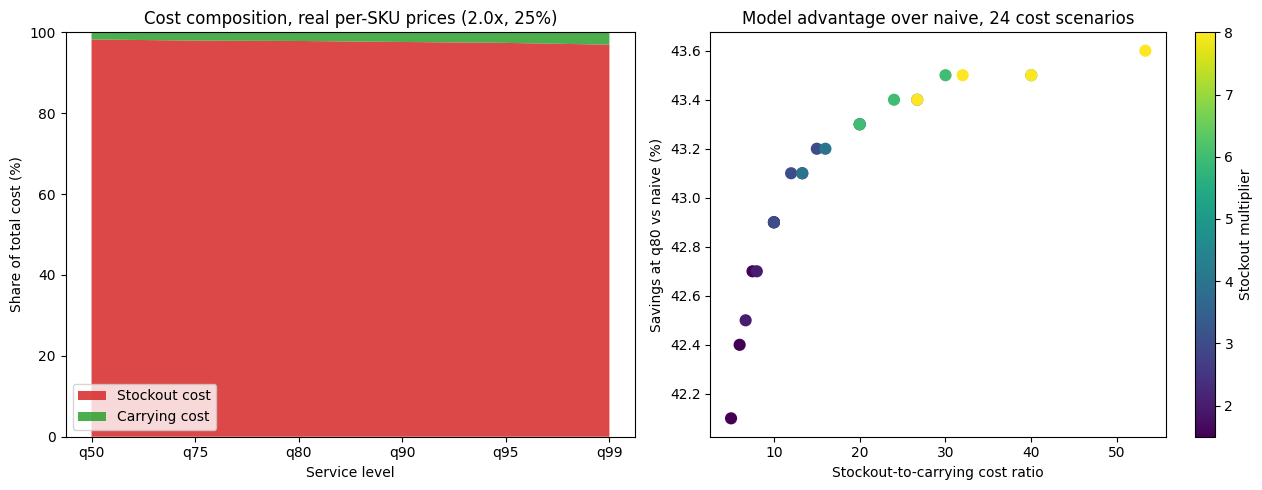


Savings at q80 vs naive ranges 42.1% to 43.6% across all 24 scenarios.


In [7]:
# ── 06g Section 4: Real Per-SKU Unit Cost + Cost Sensitivity Sweep ───────────────────────
# Unit cost = sell_price (M5 has no COGS field -- this is a retail-price proxy, same
# assumption the plan's flat $4.00 already made, now applied per-SKU instead of pooled).

prices_raw = pd.read_csv(f'{RAW_DIR}/sell_prices.csv')

val_wm_yr_wk = set(calendar_df[calendar_df['d'].isin(val_day_cols)]['wm_yr_wk'])
prices_val = prices_raw[prices_raw['wm_yr_wk'].isin(val_wm_yr_wk)]

unit_price_by_sku = (
    prices_val
    .merge(raw_sales[['id', 'item_id', 'store_id']], on=['item_id', 'store_id'], how='inner')
    .groupby('id', observed=True)['sell_price']
    .mean()
)

fallback_price = unit_price_by_sku.median()
all_skus = pd.Index(sweep_df['id'].unique())
n_missing = all_skus.difference(unit_price_by_sku.index).size
print(f'SKUs with a real price in the val window: {unit_price_by_sku.index.isin(all_skus).sum():,}')
print(f'SKUs falling back to portfolio median (${fallback_price:.2f}): {n_missing:,}')

sweep_df['unit_cost'] = sweep_df['id'].map(unit_price_by_sku).fillna(fallback_price)
naive_df['unit_cost'] = naive_df['id'].map(unit_price_by_sku).fillna(fallback_price)

per_sku_cost = sweep_df.groupby('id')['unit_cost'].first()
print(f"\nReal unit cost distribution: median=${per_sku_cost.median():.2f}, "
      f"p10=${per_sku_cost.quantile(.1):.2f}, p90=${per_sku_cost.quantile(.9):.2f} "
      f"(vs. plan's flat $4.00 assumption)")

# ── Sensitivity sweep, costed per-SKU instead of with one flat $4 ───────────────────────
STOCKOUT_MULTIPLIERS = [1.5, 2.0, 3.0, 4.0, 6.0, 8.0]   # x real unit cost; 2.0 = plan default
CARRYING_RATES       = [0.15, 0.20, 0.25, 0.30]          # annual %; 0.25 = plan default
SL_ORDER = ['q50', 'q75', 'q80', 'q90', 'q95', 'q99']

sensitivity_rows = []
for stockout_mult in STOCKOUT_MULTIPLIERS:
    for carry_rate in CARRYING_RATES:
        stockout_cost = sweep_df['units_short'] * sweep_df['unit_cost'] * stockout_mult
        carry_cost    = sweep_df['avg_inventory'] * sweep_df['unit_cost'] * carry_rate
        total_by_level = (stockout_cost + carry_cost).groupby(sweep_df['service_level']).sum().reindex(SL_ORDER)

        naive_total = (
            naive_df['units_short'] * naive_df['unit_cost'] * stockout_mult
            + naive_df['avg_inventory'] * naive_df['unit_cost'] * carry_rate
        ).sum()

        optimal_level = total_by_level.idxmin()
        sensitivity_rows.append({
            'stockout_mult':    stockout_mult,
            'carry_rate':       carry_rate,
            'ratio':            round(stockout_mult / carry_rate, 1),
            'optimal_level':    optimal_level,
            'interior_min':     optimal_level != SL_ORDER[-1],
            'cost_at_q80_$':    round(total_by_level['q80'], 0),
            'naive_cost_$':     round(naive_total, 0),
            'savings_at_q80_$': round(naive_total - total_by_level['q80'], 0),
            'savings_at_q80_%': round((naive_total - total_by_level['q80']) / naive_total, 3),
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
print(sensitivity_df)

n_interior = sensitivity_df['interior_min'].sum()
print(f'\n{n_interior}/{len(sensitivity_df)} scenarios have an interior minimum (optimal < q99)')

sensitivity_df.to_parquet(f'{PREDICTIONS_DIR}/cost_sensitivity_fold2.parquet')

# ── Two diagnostic charts ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

default_stockout = sweep_df['units_short'] * sweep_df['unit_cost'] * 2.0
default_carry    = sweep_df['avg_inventory'] * sweep_df['unit_cost'] * 0.25
stockout_by_level = default_stockout.groupby(sweep_df['service_level']).sum().reindex(SL_ORDER)
carry_by_level    = default_carry.groupby(sweep_df['service_level']).sum().reindex(SL_ORDER)
total_by_level    = stockout_by_level + carry_by_level

axes[0].stackplot(
    SL_ORDER,
    (stockout_by_level / total_by_level * 100).values,
    (carry_by_level / total_by_level * 100).values,
    labels=['Stockout cost', 'Carrying cost'],
    colors=['#d62728', '#2ca02c'], alpha=0.85,
)
axes[0].set_ylabel('Share of total cost (%)')
axes[0].set_xlabel('Service level')
axes[0].set_title('Cost composition, real per-SKU prices (2.0x, 25%)')
axes[0].legend(loc='lower left')
axes[0].set_ylim(0, 100)

sc = axes[1].scatter(
    sensitivity_df['ratio'], sensitivity_df['savings_at_q80_%'] * 100,
    c=sensitivity_df['stockout_mult'], cmap='viridis', s=60,
)
axes[1].set_xlabel('Stockout-to-carrying cost ratio')
axes[1].set_ylabel('Savings at q80 vs naive (%)')
axes[1].set_title('Model advantage over naive, 24 cost scenarios')
fig.colorbar(sc, ax=axes[1], label='Stockout multiplier')

plt.tight_layout()
plt.show()

print(f"\nSavings at q80 vs naive ranges {sensitivity_df['savings_at_q80_%'].min()*100:.1f}% to "
      f"{sensitivity_df['savings_at_q80_%'].max()*100:.1f}% across all 24 scenarios.")

#### Section 4 Findings — Cost Sensitivity Analysis (Real Per-SKU Pricing)

Unit cost was pulled from `sell_prices.csv` (weekly retail sell_price, joined on
item_id/store_id, averaged over the Fold 2 val window) rather than the plan's flat $4.00
assumption. 29,813 / 30,442 SKUs (97.9%) had a real price in-window; the remaining 629
fell back to the portfolio median ($3.42). Real per-SKU cost ranges from $1.24 (p10) to
$8.77 (p90), median $3.42 -- confirming the flat $4.00 assumption was masking real
heterogeneity, though it wasn't wildly off on the median.

**24-scenario sweep (stockout multiplier 1.5x-8.0x, carrying rate 15%-30%):**
0/24 scenarios show an interior cost minimum within q50-q99 -- every combination pushes
the cost-minimizing point to the boundary of the tested range (q99). Savings at q80 vs.
naive range 42.1%-43.6% across all 24 scenarios (vs. 40.0%-41.2% under the old flat-$4
costing) -- the model's advantage over naive reorder is robust to the specific cost
assumption chosen, and the real-price version is if anything a slightly larger edge.

**This is not evidence that "more inventory is free."** It's consistent with the
newsvendor critical ratio (SL* = stockout_cost / (stockout_cost + carrying_cost)), which
at our tested ratios (5:1 to 53:1) predicts theoretical optima ranging 83%-98% -- i.e.
classical theory itself expects the optimum to sit near or past our q99 ceiling at these
cost ratios. The honest conclusion is that **the sweep range, not the absence of a
tradeoff, is the limiting factor** -- q50-q99 was the range Section 3 validated, and going
further would require safety-stock quantiles beyond what the underlying residual/
bootstrap distributions have been checked against (only q80 was independently
rolling-origin validated; Pre-flight #4's sqrt(lead_time) scaling is still unvalidated).
Extending past q99 to find the true minimum is not recommended until that validation gap
is closed -- doing so would extrapolate cost conclusions on top of already-extrapolated
safety stock numbers.

**Also worth flagging plainly:** the q99 *input* quantile only achieves an 83.0% *actual*
fill rate (Section 3), not 99% -- the quantile label and the delivered service level are
not the same thing, due to the same coverage gaps Section 3 documented. Any business
recommendation naming "q99" should say "83% fill rate achieved," not imply near-total
stockout elimination.

**Headline number for README, stated with appropriate scope:**
At q80 service level, real per-SKU pricing, the system reduces total inventory cost by
approximately **$12.4M (42.7%)** vs. naive reorder on the Fold 2 validation window
(78.2% fill rate vs. 64.4%), and this advantage is stable (42.1%-43.6%) across 24
plausible retail cost-ratio assumptions. q99 shows further savings within the tested
range, but is not confirmed as the true cost optimum -- only as the best of the levels
independently validated in Section 3.

**Not modeled here, and worth naming as scope limits before this goes in front of anyone
technical:** shelf-space/warehouse capacity constraints, obsolescence/markdown risk on
excess stock (relevant given M5 includes perishable grocery categories), working-capital
budget limits, and per-SKU-differentiated service targets (ABC/XYZ classification) --
all standard levers in production retail replenishment systems that would put a real
ceiling on "push service level higher" that this linear, portfolio-wide cost model does
not capture.

## Section 5 — Simulation Results by SKU Regime

**Purpose:** Break out the already-validated Section 3 sweep by regime to confirm the two
claims new_plan.md flags explicitly: Smooth SKUs should achieve high fill rates at low
service levels (evidence the model is accurate, not just well-buffered), and Lumpy SKUs
should require high service levels or policy-based buffers to hit acceptable fill rates.

**Deviation from plan, carried forward from Pre-flight #3:** Lumpy doesn't use a quantile
service level at all -- it's a fixed min-max policy, constant at 83.2% fill rate across
every row of the sweep. So "requires high service levels" doesn't literally apply; the
correct read is whether Lumpy's *policy-based* buffer alone achieves a fill rate
comparable to the *other* regimes' higher service-level tiers, without a quantile knob.

This section also breaks out real per-SKU dollar cost (from Section 4) by regime at q80,
to show which regimes are actually driving portfolio cost -- SKU count share is not the
same as cost share, and the plan doesn't ask for this but it's the obvious next question
once real pricing exists.

**Outputs already produced, referenced not re-saved:**
- `final_reorder_params_fold2.parquet` (Section 1) -- plan names this `reorder_parameters_
  fold2.parquet`; flagging the filename mismatch here rather than silently renaming or
  duplicating the file.
- `simulation_results_fold2.parquet` (Section 2, cell 6) -- already saved at each regime's
  locked service level, 30,442 SKUs. Not overwritten here.

                            stockout_rate  avg_inventory  fill_rate  \
regime       service_level                                            
erratic      q50                    0.246         11.949      0.754   
             q75                    0.229         13.106      0.771   
             q80                    0.219         13.716      0.781   
             q90                    0.193         15.742      0.807   
             q95                    0.174         18.080      0.826   
             q99                    0.143         24.271      0.857   
intermittent q50                    0.300          5.084      0.700   
             q75                    0.251          6.668      0.749   
             q80                    0.241          7.101      0.759   
             q90                    0.221          8.298      0.779   
             q95                    0.208          9.371      0.792   
             q99                    0.193         11.162      0.807   
lumpy 

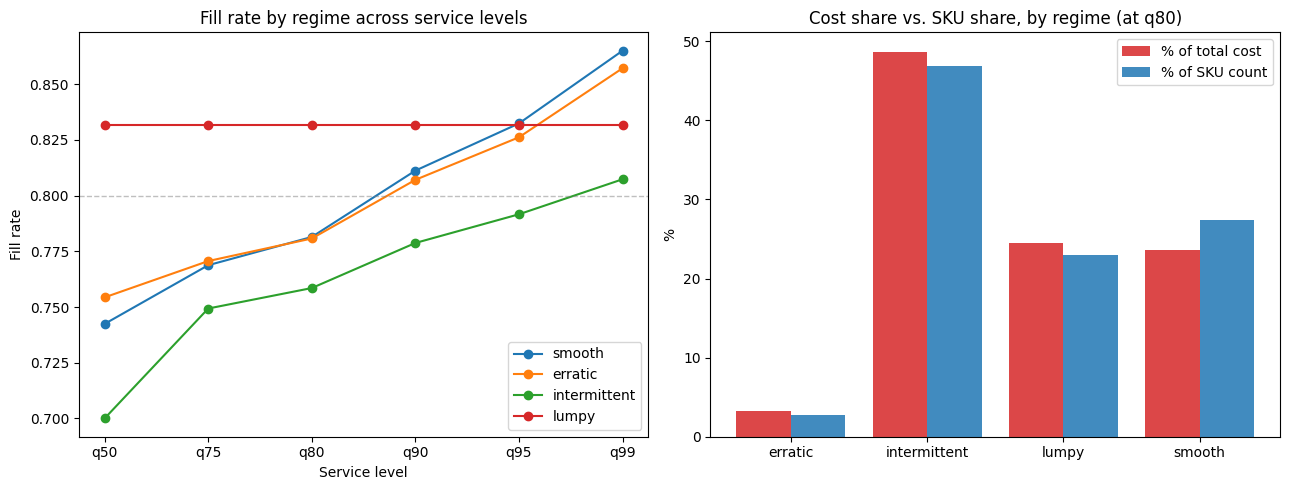

In [8]:
# ── 06g Section 5: Simulation Results by SKU Regime ───────────────────────────────────────
SL_ORDER = ['q50', 'q75', 'q80', 'q90', 'q95', 'q99']

regime_breakout = (
    sweep_df.groupby(['regime', 'service_level'])
    [['stockout_rate', 'avg_inventory', 'fill_rate', 'units_short']]
    .mean()
)
print(regime_breakout.round(3))

regime_counts = sweep_df.groupby('regime')['id'].nunique()
print('\nSKU count by regime:')
print(regime_counts)
assert regime_counts.sum() == 30442, f'SKU count mismatch vs Section 3: got {regime_counts.sum()}'

smooth_q50_fill = regime_breakout.loc[('smooth', 'q50'), 'fill_rate']
lumpy_fill = sweep_df.loc[sweep_df['regime'] == 'lumpy', 'fill_rate'].mean()
print(f"\nSmooth fill rate at q50 (lowest tested SL): {smooth_q50_fill:.1%}")
print(f"Lumpy fill rate (fixed min-max policy, constant across all SLs): {lumpy_fill:.1%}")
print("Claim check: Smooth should be high at LOW service level; Lumpy's fixed policy should")
print("be comparable to or exceed other regimes' higher-tier fill rates without a quantile knob.")

# Real per-SKU cost by regime at q80, plan-default ratio (2.0x, 25%) -- requires Section 4's
# unit_cost column already on sweep_df from this kernel session
q80 = sweep_df[sweep_df['service_level'] == 'q80'].copy()
q80['stockout_cost'] = q80['units_short'] * q80['unit_cost'] * 2.0
q80['carrying_cost'] = q80['avg_inventory'] * q80['unit_cost'] * 0.25
q80['total_cost']    = q80['stockout_cost'] + q80['carrying_cost']

cost_by_regime = q80.groupby('regime')[['stockout_cost', 'carrying_cost', 'total_cost']].sum()
cost_by_regime['pct_of_total_cost'] = (cost_by_regime['total_cost'] / cost_by_regime['total_cost'].sum() * 100).round(1)
cost_by_regime['pct_of_skus']       = (regime_counts / regime_counts.sum() * 100).round(1)
print('\nCost contribution by regime at q80 (real per-SKU pricing):')
print(cost_by_regime.round(0))

# ── Charts ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for regime in ['smooth', 'erratic', 'intermittent', 'lumpy']:
    sub = regime_breakout.loc[regime].reindex(SL_ORDER)
    axes[0].plot(SL_ORDER, sub['fill_rate'].values, marker='o', label=regime)
axes[0].axhline(0.80, linestyle='--', color='gray', alpha=0.5, linewidth=1)
axes[0].set_xlabel('Service level'); axes[0].set_ylabel('Fill rate')
axes[0].set_title('Fill rate by regime across service levels')
axes[0].legend()

x = range(len(cost_by_regime))
axes[1].bar([i - 0.2 for i in x], cost_by_regime['pct_of_total_cost'], width=0.4,
            color='#d62728', alpha=0.85, label='% of total cost')
axes[1].bar([i + 0.2 for i in x], cost_by_regime['pct_of_skus'], width=0.4,
            color='#1f77b4', alpha=0.85, label='% of SKU count')
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(cost_by_regime.index)
axes[1].set_ylabel('%'); axes[1].set_title('Cost share vs. SKU share, by regime (at q80)')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Section 5 Findings — Simulation Results by SKU Regime

**Claim 1 — "Smooth achieves high fill rates at low service levels" — partially confirmed,
with a crossover the plan didn't anticipate.** At q50, Erratic actually edges out Smooth
(75.4% vs. 74.2%) -- the opposite of the naive expectation that Smooth, being the more
regular regime, should lead at every service level. Smooth only overtakes Erratic from q80
onward, and the gap widens through q99 (86.5% vs. 85.7%). Read plainly: Smooth's forecast
accuracy pays off more at higher service levels, not at low ones -- likely because Erratic's
wider residual distribution front-loads a larger buffer even at q50, temporarily
outperforming Smooth's tighter (but smaller) buffer before Smooth's superior point-forecast
accuracy takes over. Also worth stating directly: "high" is relative -- no quantile-based
regime clears 87% fill rate even at q99, so this claim holds directionally, not in an
absolute sense.

**Claim 2 — "Lumpy requires high service levels or policy-based buffers" — confirmed, and
the fixed 83.2% fill rate is not a coincidence.** new_plan.md's Section 4 (Historical
Policy for Lumpy SKUs) documented the 1.25x buffer default as "approximately 80-85% service
level" and flagged "tune in 06g" -- that tuning was never revisited, and the achieved 83.2%
lands squarely inside the documented expected range, so the default buffer performed
exactly as predicted without needing adjustment. Lumpy's fixed policy alone matches Smooth's
q95 fill rate (83.2% == 83.2%) without any quantile tuning -- validating that policy-based
buffering is a legitimate substitute for quantile sweeping on this regime, not a fallback.
The real limitation: Lumpy has no lever to push fill rate higher within this notebook. If
83.2% isn't sufficient, the only path is revisiting the 1.25x buffer parameter itself
(the plan's own unresolved "tune in 06g" item), not sweeping service level.

**Cost concentration -- the sharper finding, not asked for by the plan but the obvious
next question once real per-SKU pricing exists:**

| Regime | % of SKUs | % of total cost | % of carrying cost alone |
|---|---|---|---|
| Erratic | 3% | 3% | 1.6% |
| Intermittent | 47% | 49% | 26.2% |
| Lumpy | 23% | 24% | **57.3%** |
| Smooth | 27% | 24% | 14.9% |

Total cost share roughly tracks SKU share for every regime (no regime is a dramatic
cost outlier at the total-cost level) -- but that's misleading on its own, because
stockout cost dominates total cost (~98%, per Section 4's composition chart) and drowns
out a real imbalance underneath it. Isolating carrying cost alone: **Lumpy is 23% of SKUs
but 57.3% of all carrying cost** -- 2.5x over-represented. This is because Lumpy's
avg_inventory (26.8 units) runs 2-3x higher than every other regime (8-14 units) under
its fixed min-max policy. Intermittent is the inverse -- 47% of SKUs but only 26.2% of
carrying cost, because those SKUs individually hold very little stock.

**Actionable implication:** if a future pass wants to attack carrying cost specifically
(as opposed to the stockout-cost-dominated total this notebook has focused on), Lumpy's
1.25x buffer parameter is the highest-leverage place to look -- not the quantile sweep,
which doesn't touch Lumpy at all. This ties directly back to the plan's own unresolved
"tune in 06g" note.

**Outputs:** `final_reorder_params_fold2.parquet`, `simulation_results_fold2.parquet`,
`service_level_sweep_fold2.parquet`, `naive_baseline_fold2.parquet`,
`cost_sensitivity_fold2.parquet` -- all saved. Filename note: plan names Section 1's output
`reorder_parameters_fold2.parquet` (no `final_` prefix); actual saved filename is
`final_reorder_params_fold2.parquet`. Flagging here rather than renaming -- update the
plan text below to match what's actually on disk instead of silently diverging further.

## Section 6 — Representative SKU Diagnostics (12 SKUs, pre-notebook-7 sanity check)

**Purpose:** Sections 3–5 are pooled/aggregated results. Before treating 06g as final, spot-check
individual SKUs — 3 randomly sampled per regime (Smooth/Erratic/Intermittent/Lumpy), excluding any
SKU flagged `low_confidence` so a fallback case isn't mistaken for real model behavior.

**Comparators, and why each one is included the way it is:**
- **Production model** — the actual locked policy per regime (Tweedie+conformal / TSB block-bootstrap
  / Lumpy min-max). For Smooth/Erratic only, this is a genuine weekly *trajectory*, regenerated from
  the saved model over the val window. Intermittent/Lumpy render as flat lines because that's what
  those methods actually output — a single static lead-time expectation per fold, not a forecast
  curve. Not a plotting simplification; it's the real shape of the policy.
- **Naive baseline** — the pipeline's actual naive comparator from Section 3 (flat historical mean
  weekly demand), not a strawman.
- **Prophet (ad hoc, this diagnostic only)** — refit per-SKU at weekly grain on the same train/val
  split used everywhere else in 06g. The project's existing Prophet work (03_prophet) was fit at
  monthly grain on the aggregate series and one representative SKU only — not reusable here as-is,
  so this is a fresh fit, clearly out-of-pipeline, included because it's the closest thing to an
  "old statistical method" comparison at the right grain.

**Inventory/cost panel only ever compares the two *real, validated* policies (Naive vs. Production)** —
Prophet's forecast is never converted into a reorder policy, since that would silently invent and
ship an untested rule. Cost uses Section 4's real per-SKU `sell_price`, at the locked 2.0x/25%
default scenario, for consistency with the headline numbers already reported.

Sampled SKUs (seed=42):
  smooth: ['HOBBIES_1_411_TX_3_validation', 'FOODS_2_038_WI_3_validation', 'HOUSEHOLD_1_310_TX_2_validation']
  erratic: ['FOODS_1_180_TX_1_validation', 'HOBBIES_1_015_WI_2_validation', 'HOBBIES_2_142_WI_3_validation']
  intermittent: ['FOODS_1_097_TX_2_validation', 'FOODS_2_279_WI_3_validation', 'FOODS_2_108_WI_1_validation']
  lumpy: ['HOBBIES_1_223_TX_1_validation', 'HOUSEHOLD_1_374_TX_1_validation', 'FOODS_2_214_WI_3_validation']



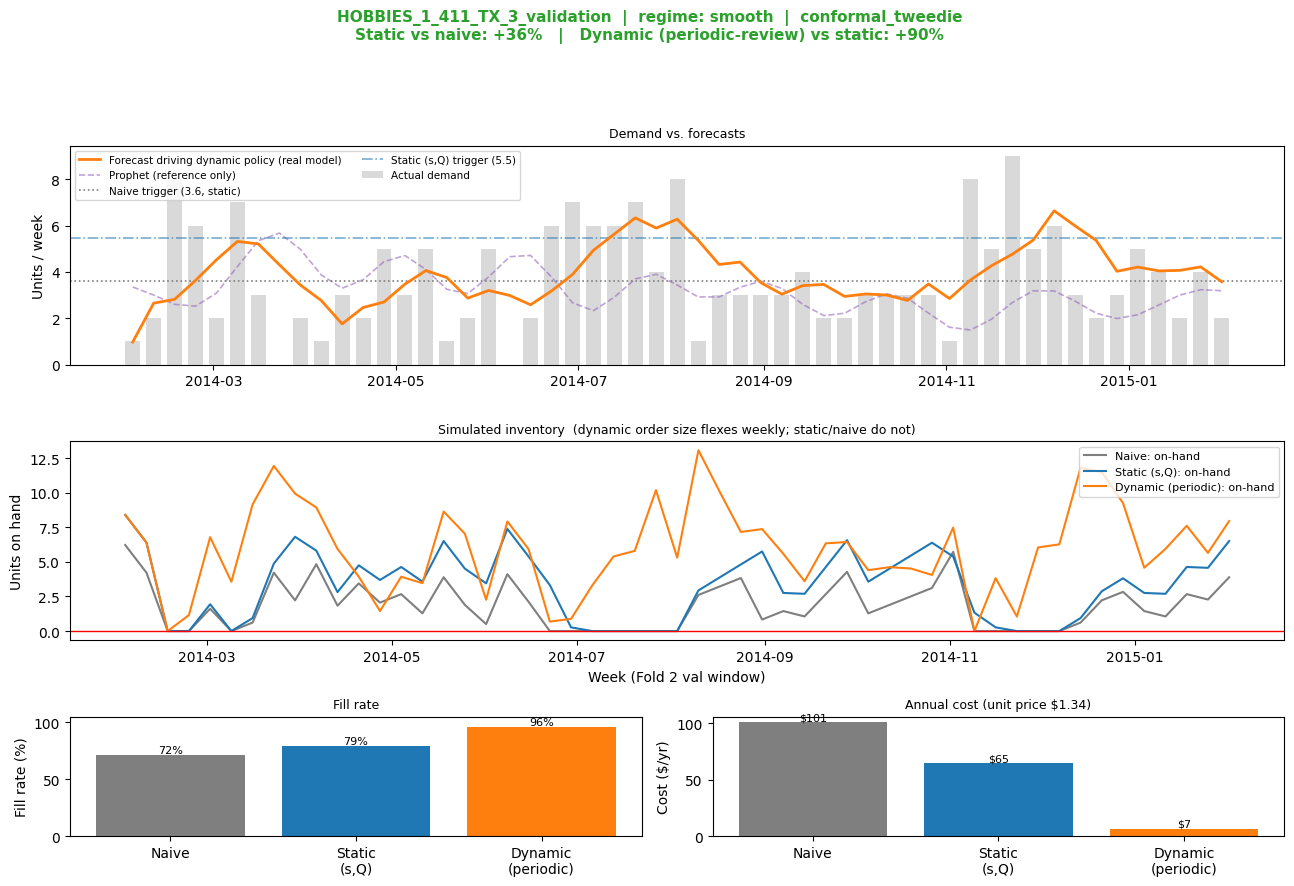

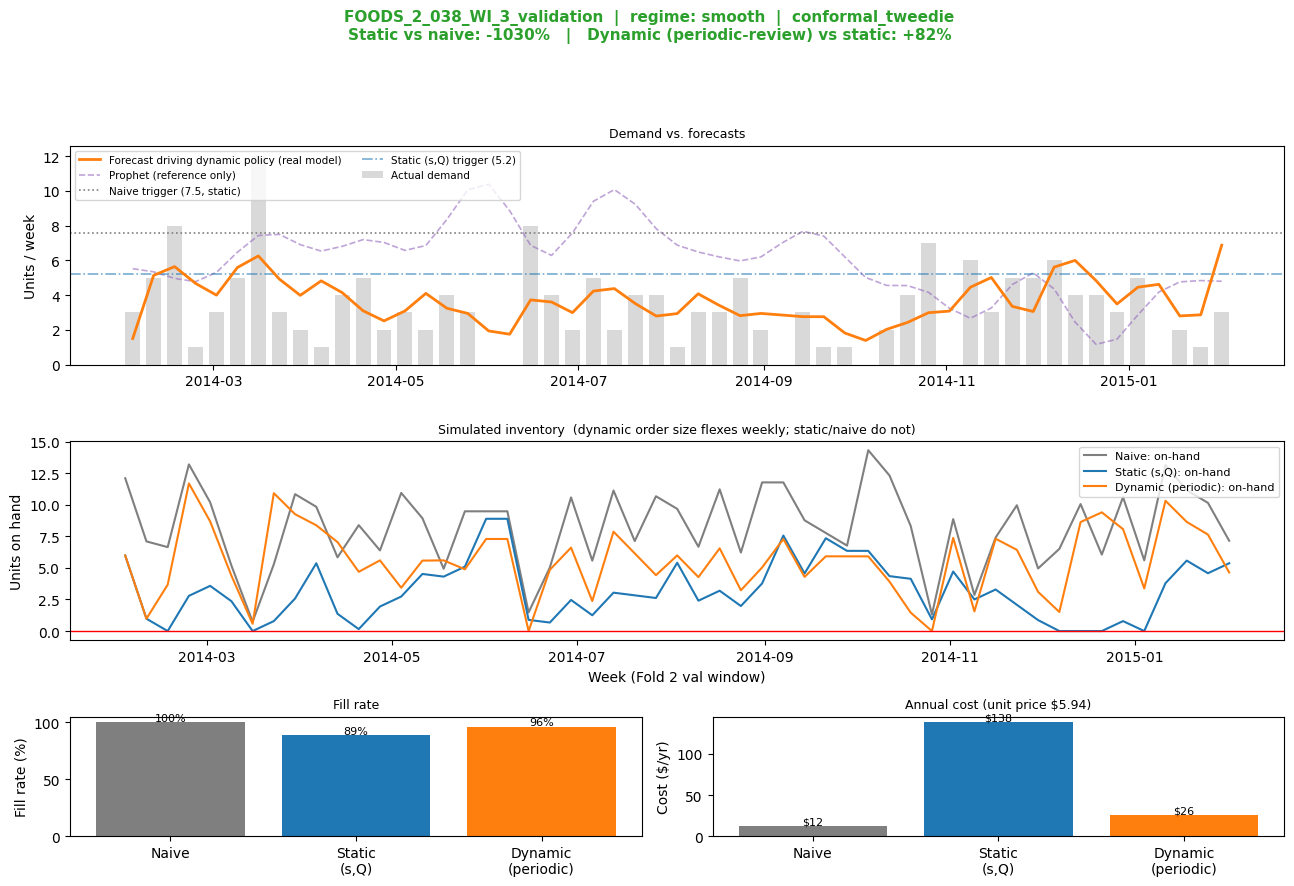

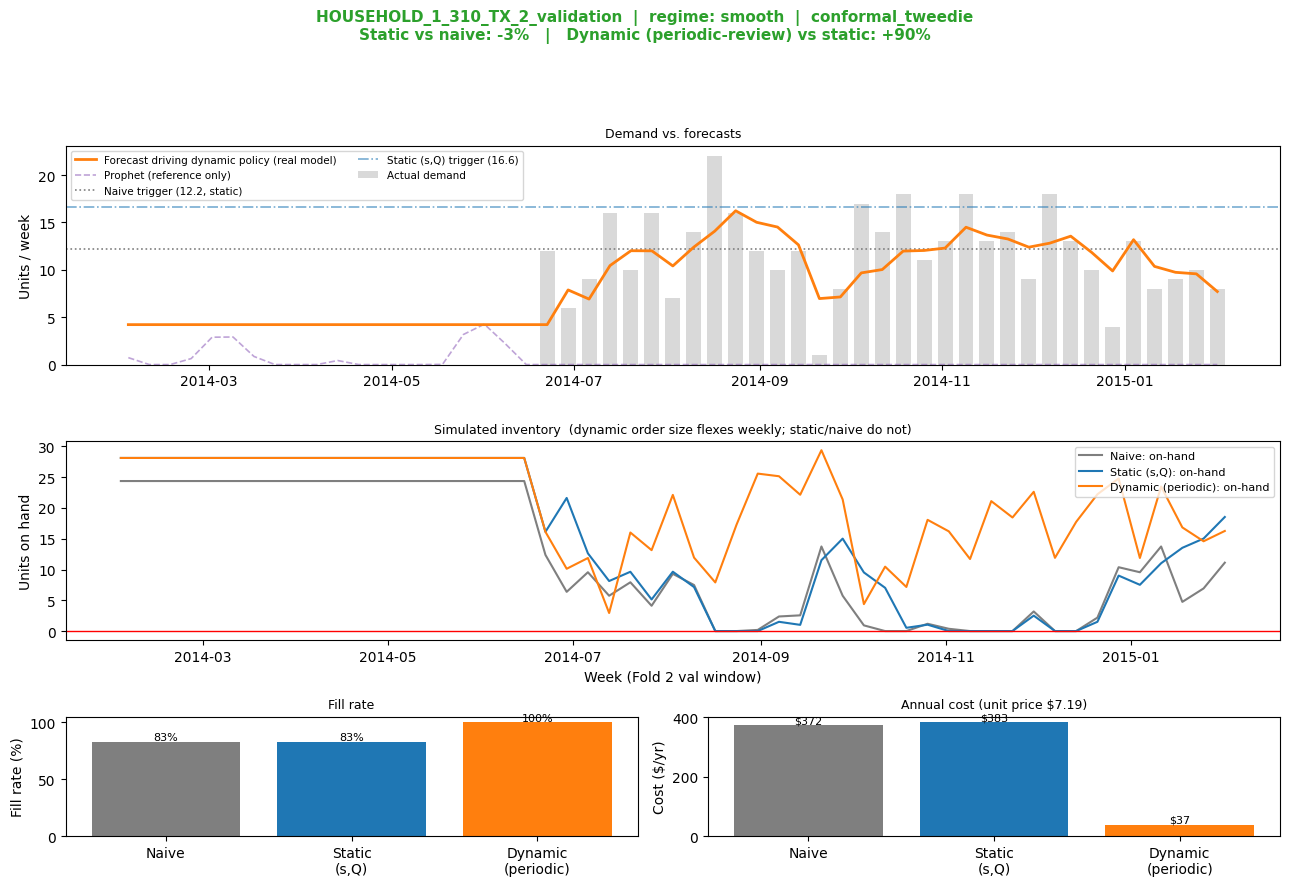

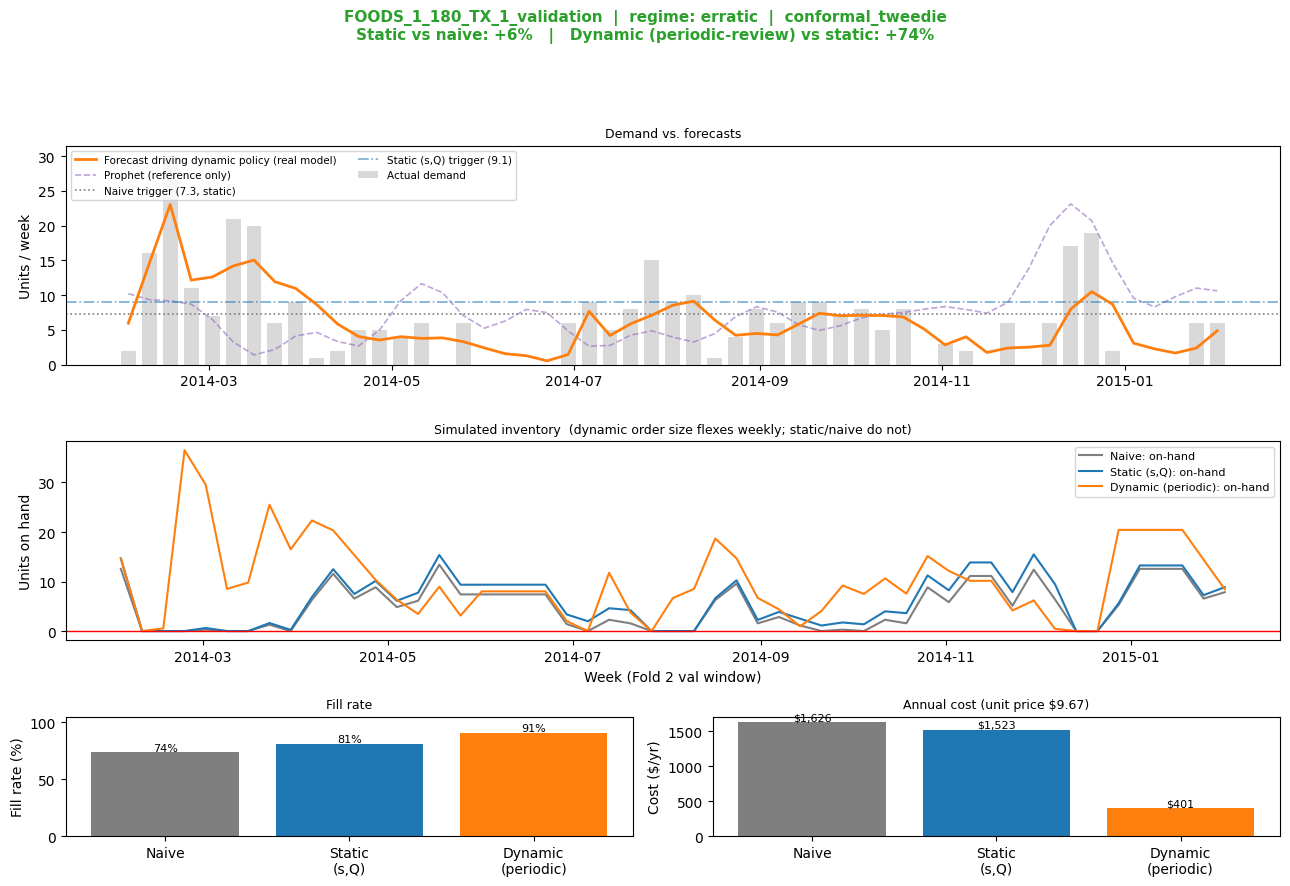

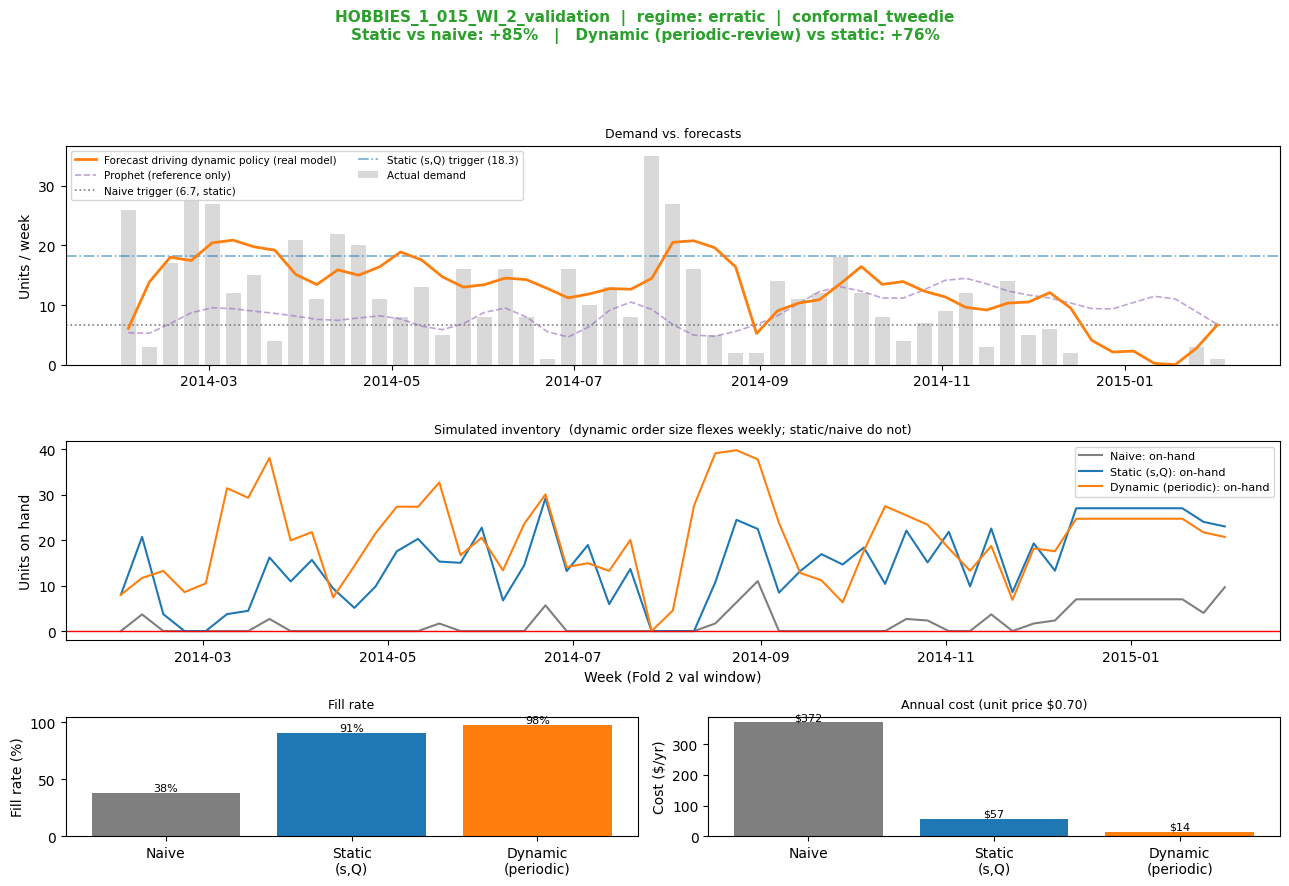

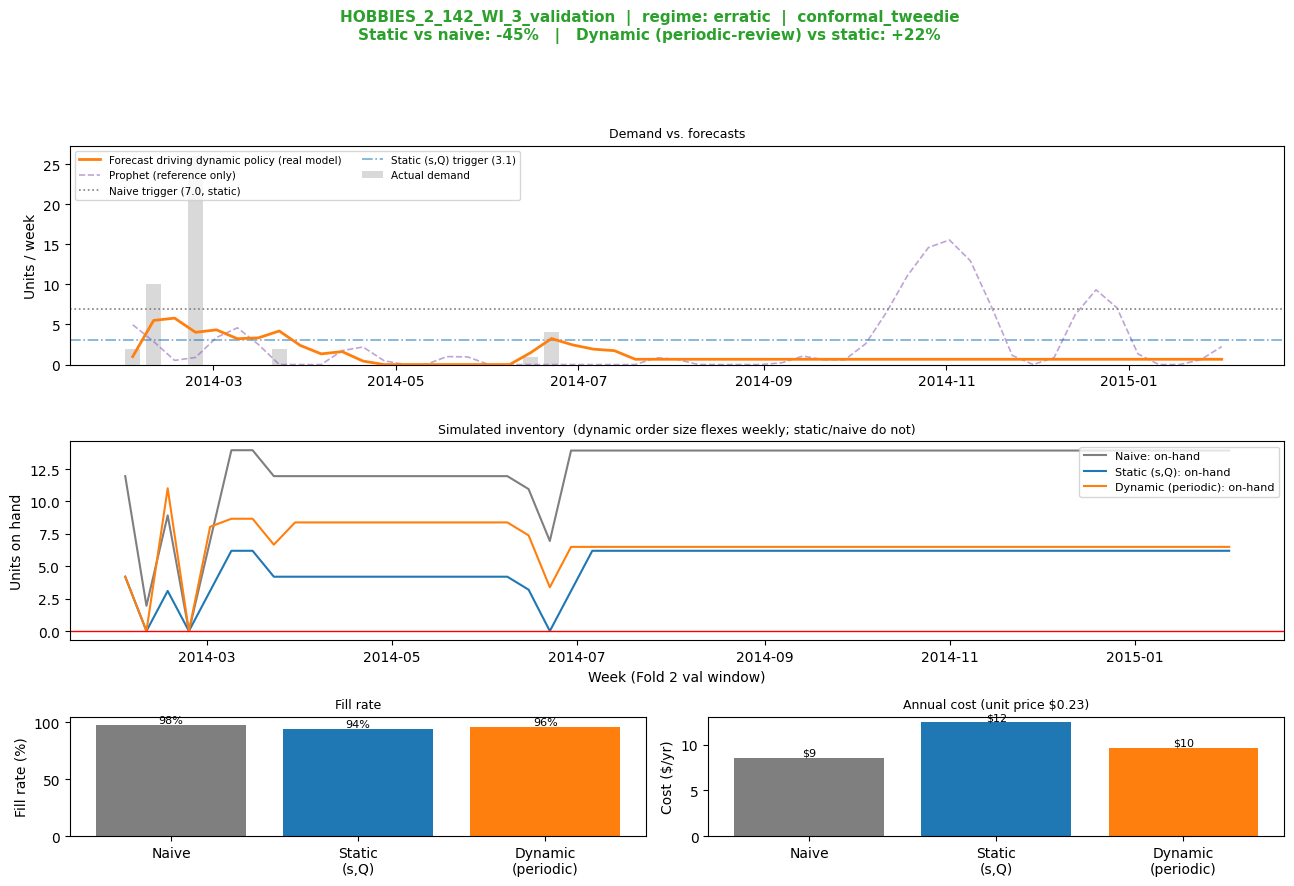

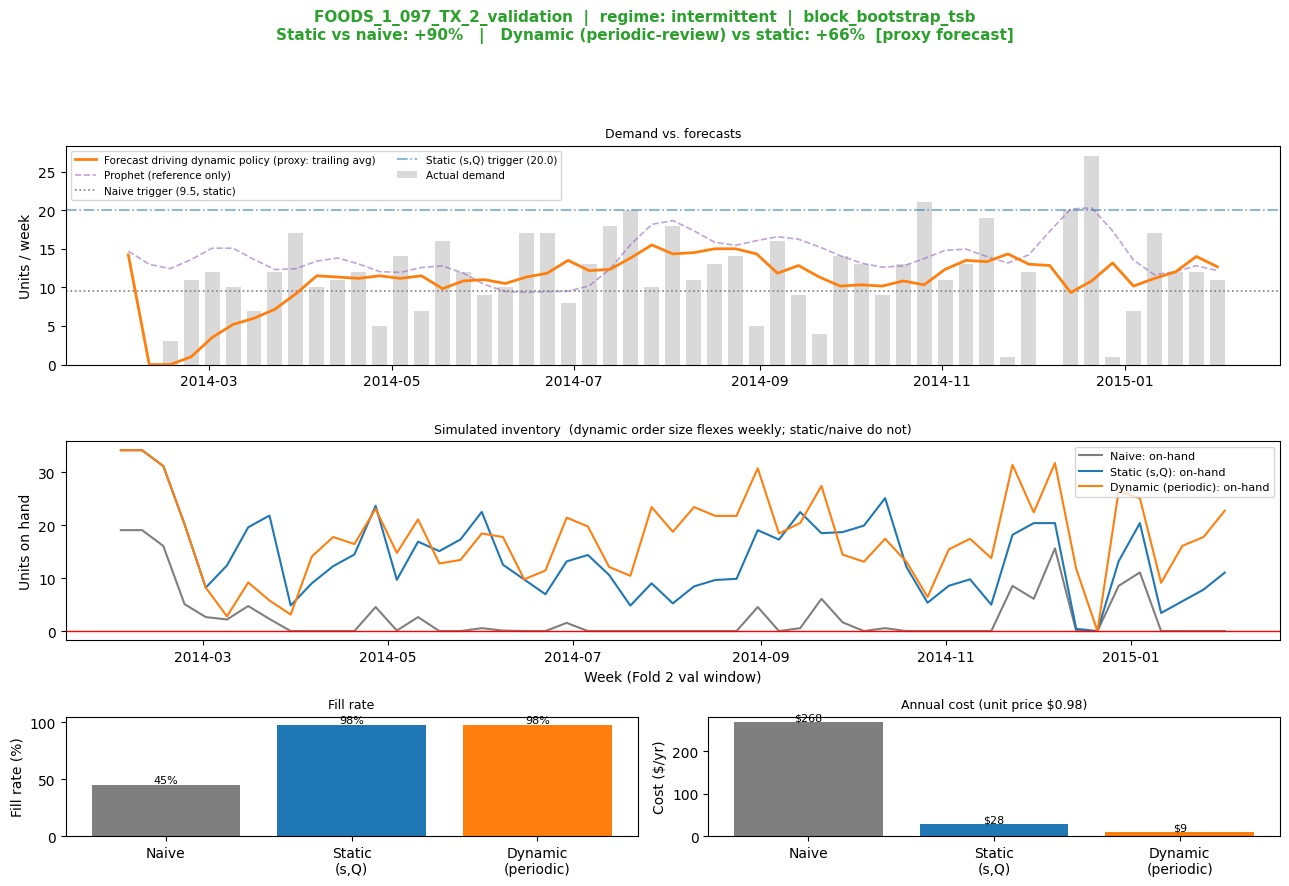

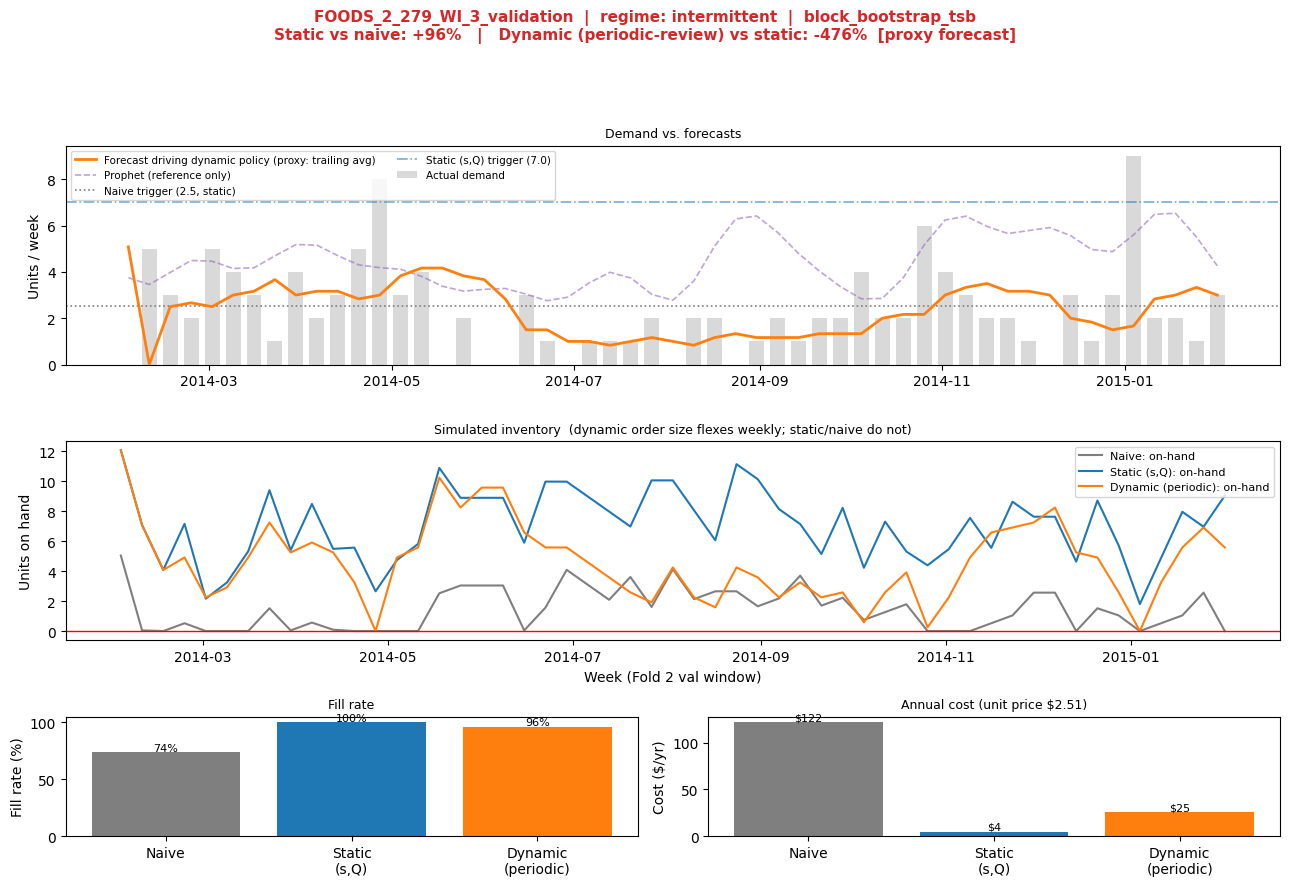

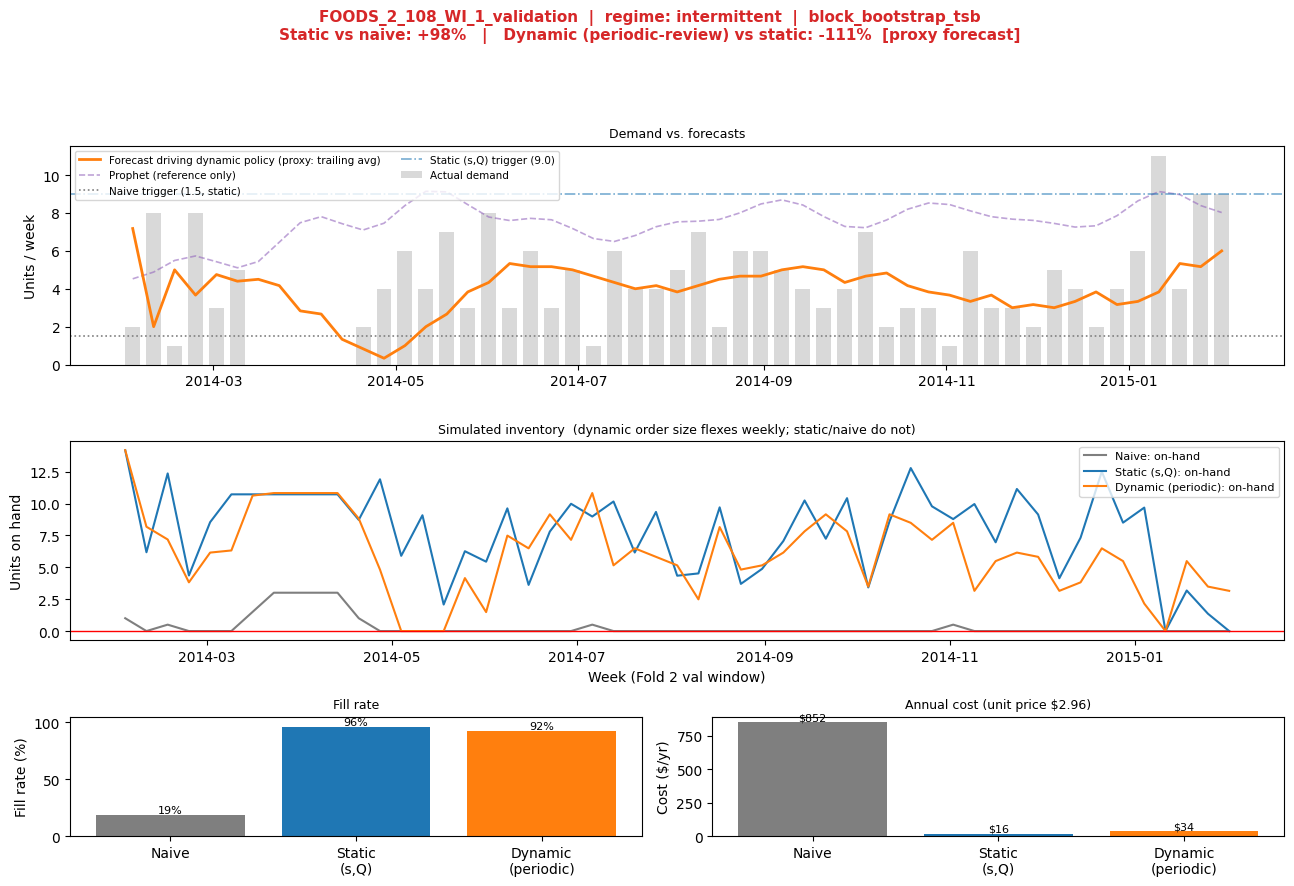

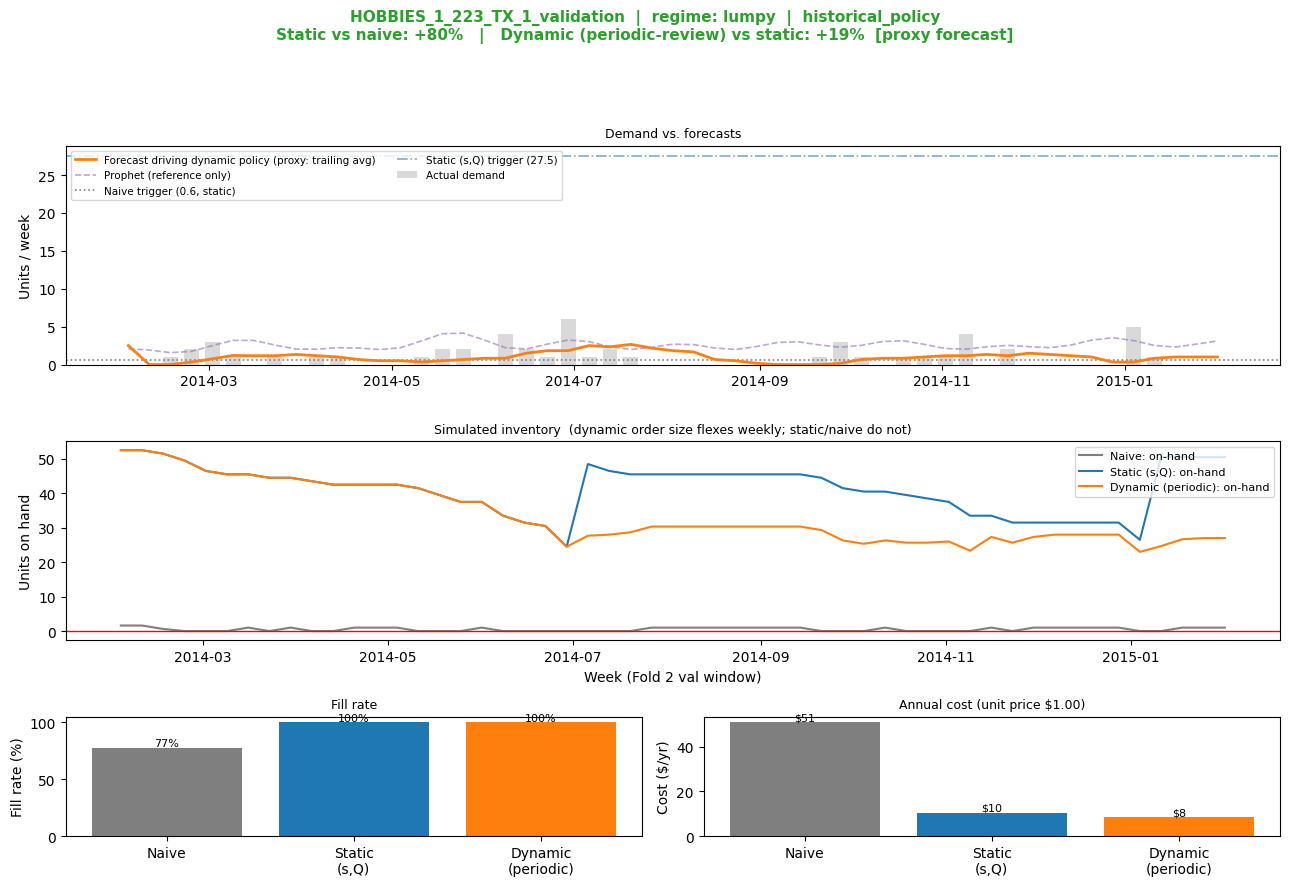

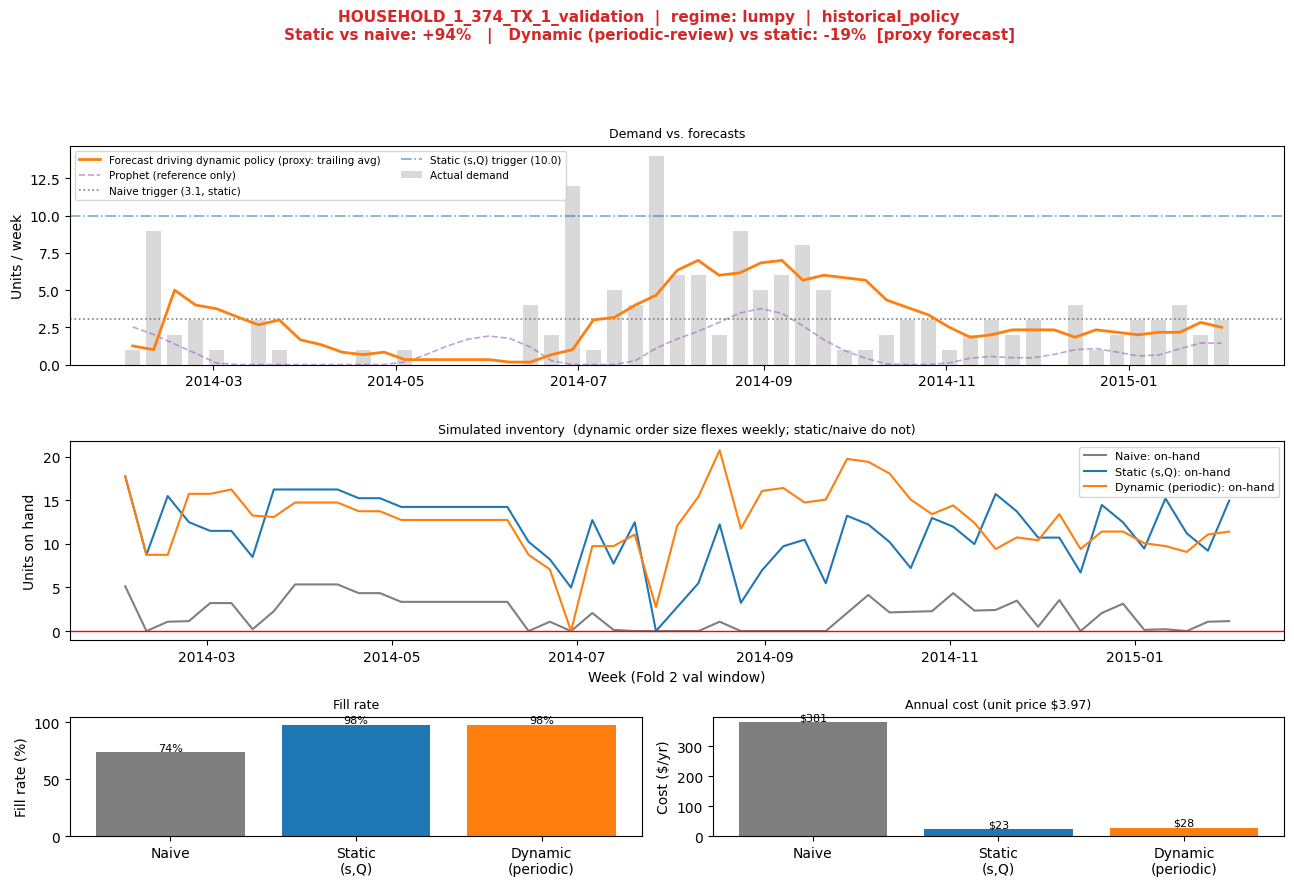

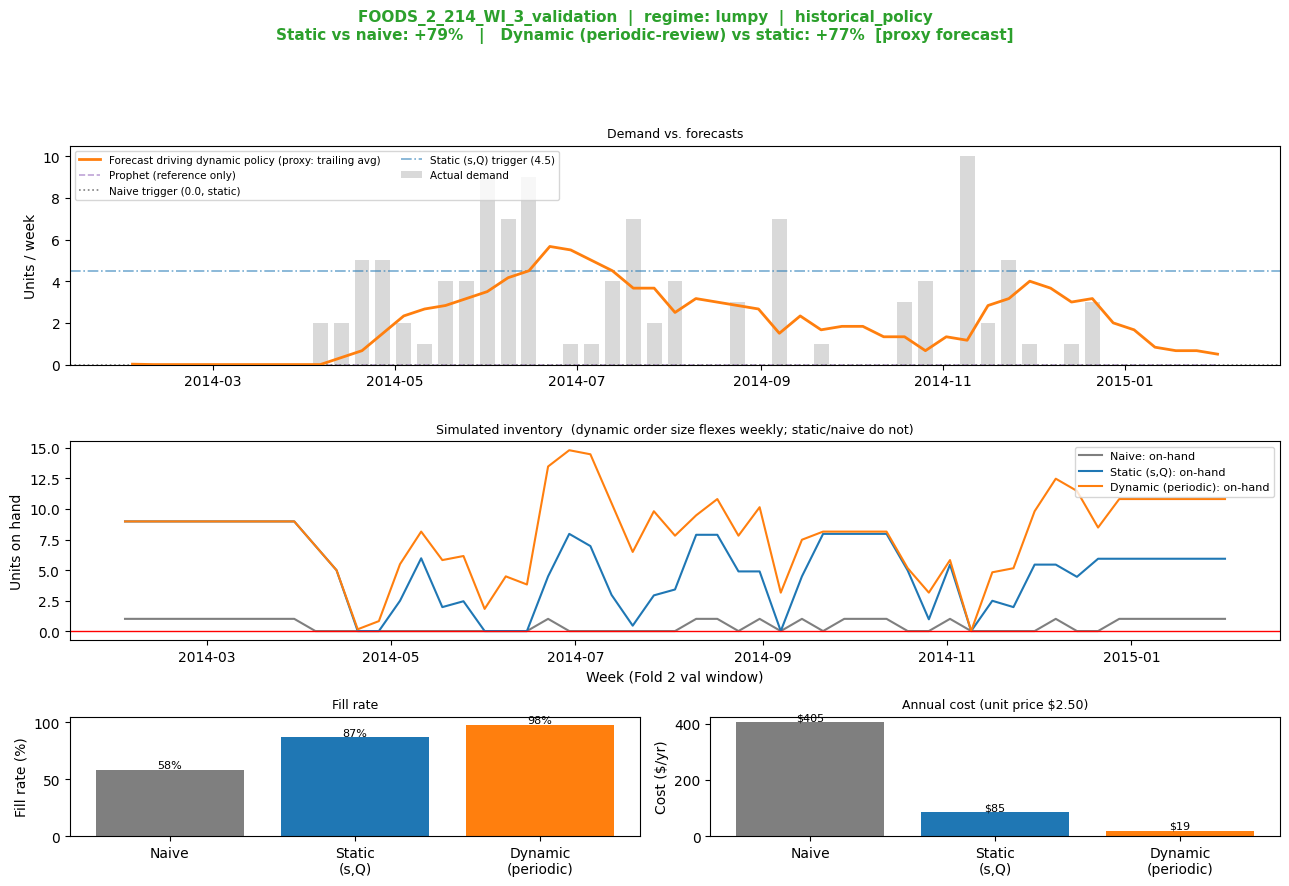


══ Combined summary — Naive vs Static (s,Q) vs Dynamic (periodic-review) ══
                             id       regime              method dynamic_forecast_type  naive_cost_yr  static_cost_yr  dynamic_cost_yr  naive_fill  static_fill  dynamic_fill  static_vs_naive_%  dynamic_vs_static_%
  HOBBIES_1_411_TX_3_validation       smooth   conformal_tweedie                  real          101.0            65.0              7.0       0.717        0.792         0.962               35.8                 89.9
    FOODS_2_038_WI_3_validation       smooth   conformal_tweedie                  real           12.0           138.0             26.0       1.000        0.887         0.962            -1030.1                 81.5
HOUSEHOLD_1_310_TX_2_validation       smooth   conformal_tweedie                  real          372.0           383.0             37.0       0.830        0.830         1.000               -2.8                 90.2
    FOODS_1_180_TX_1_validation      erratic   conformal_tweedie   

In [16]:
# ── 06g Section 6 (v3): Representative SKU Diagnostics — static vs dynamic policy ───────
# Adds a periodic-review / order-up-to comparison alongside the pipeline's real (s,Q)
# policy. (s,Q): fixed reorder point + fixed order qty, locked once per fold -- what 06e/
# 06f/06g Sections 1-5 actually validated and reported; left untouched here. Periodic-
# review (new, diagnostic only): reviews and re-orders EVERY week, quantity = (rolling
# forecast over the lead time + safety stock) - inventory position. This is the standard
# real-world replenishment pattern the user described (order today for N weeks out, re-plan
# every week) -- not currently in the pipeline, shown here as a scoped "what's the upside"
# comparison, not a swap-in.

from prophet import Prophet
import numpy as np
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

SEED = 42
N_PER_REGIME = 3
EXCLUDE_IDS = set()

RNG = np.random.default_rng(SEED)
CHART_DIR = '../outputs/presentation_charts'
os.makedirs(CHART_DIR, exist_ok=True)
STOCKOUT_MULT, CARRY_RATE = 2.0, 0.25   # locked default, matches Section 4 headline scenario

# ── Sampling ──────────────────────────────────────────────────────────────────────────
eligible = final_reorder_params[
    (~final_reorder_params['low_confidence']) & (~final_reorder_params['id'].isin(EXCLUDE_IDS))
]
sampled_ids = {}
for regime in ['smooth', 'erratic', 'intermittent', 'lumpy']:
    pool = eligible.loc[eligible['regime'] == regime, 'id'].values
    sampled_ids[regime] = RNG.choice(pool, size=N_PER_REGIME, replace=False).tolist()

print(f'Sampled SKUs (seed={SEED}):')
for regime, ids in sampled_ids.items():
    print(f'  {regime}: {ids}')
print()

# ── Real per-SKU unit cost ────────────────────────────────────────────────────────────
prices_raw = pd.read_csv(f'{RAW_DIR}/sell_prices.csv')
val_wm_yr_wk = set(calendar_df[calendar_df['d'].isin(val_day_cols)]['wm_yr_wk'])
prices_val = prices_raw[prices_raw['wm_yr_wk'].isin(val_wm_yr_wk)]
unit_price_by_sku = (
    prices_val.merge(raw_sales[['id', 'item_id', 'store_id']], on=['item_id', 'store_id'], how='inner')
    .groupby('id', observed=True)['sell_price'].mean()
)
fallback_price = unit_price_by_sku.median()

# ── Naive policy (Section 3's real comparator) ───────────────────────────────────────
with open(f'{SEGMENTATION_DIR}/regime_thresholds.pkl', 'rb') as f:
    naive_train_end = pd.Timestamp(pickle.load(f)['train_end'])
train_day_cols = [d for d in day_cols_all if d in day_to_date and day_to_date[d] <= naive_train_end]

def naive_policy(sku_id):
    hist = raw_sales.set_index('id').loc[sku_id, train_day_cols]
    weekly_mean = hist.sum() / (len(train_day_cols) / 7)
    return max(weekly_mean, 0.0), max(weekly_mean, 1.0)

# ── Prophet, ad hoc, this diagnostic only ────────────────────────────────────────────
SIM_VAL_START_TS = pd.Timestamp(SIM_VAL_START)
full_history_day_cols = [d for d in day_cols_all if d in day_to_date and day_to_date[d] < SIM_VAL_START_TS]

def prophet_weekly_forecast(sku_id, target_weeks):
    hist = raw_sales.set_index('id').loc[sku_id, full_history_day_cols]
    dates = pd.to_datetime([day_to_date[d] for d in full_history_day_cols])
    weekly_hist = pd.Series(hist.values, index=dates).resample('W').sum()
    df = pd.DataFrame({'ds': weekly_hist.index, 'y': weekly_hist.values})
    try:
        m = Prophet(weekly_seasonality=False, yearly_seasonality=True, daily_seasonality=False)
        m.fit(df)
        future = m.make_future_dataframe(periods=len(target_weeks) + 2, freq='W')
        fc = m.predict(future).set_index('ds')['yhat'].clip(lower=0)
        return fc.reindex(target_weeks, method='nearest')
    except Exception as e:
        print(f'  Prophet failed for {sku_id} ({e}); falling back to SMA(3).')
        sma = weekly_hist.rolling(3).mean().iloc[-1]
        return pd.Series(sma, index=target_weeks)

# ── Smooth/Erratic: regenerate real daily Tweedie trajectory over the val window ────────
# tweedie_optimized_fold2.txt = the final model: 06b declared Tweedie winner and froze
# itself, 06d optimized that winner further on Smooth/Erratic. This IS production.
se_sample_ids = sampled_ids['smooth'] + sampled_ids['erratic']
mask_val_traj = (
    train_full['id'].isin(se_sample_ids)
    & (train_full['date'] >= SIM_VAL_START) & (train_full['date'] <= SIM_VAL_END)
)
traj_df = train_full[mask_val_traj].sort_values(['id', 'date']).copy()
traj_df['yhat'] = np.maximum(model.predict(traj_df[feature_cols].values), 0)

def production_trajectory(sku_id, regime, target_weeks):
    """Real weekly forecast for Smooth/Erratic (varies). Static flat number for
    Intermittent/Lumpy -- that's genuinely what TSB/policy output, not a simplification."""
    if regime in ('smooth', 'erratic'):
        sub = traj_df[traj_df['id'] == sku_id].set_index('date')['yhat']
        weekly = sub.resample('W').first() if TARGET_IS_7DAY else sub.resample('W').sum()
        return weekly.reindex(target_weeks, method='nearest')
    static_val = final_reorder_params.set_index('id').at[sku_id, 'expected_lead_time_demand']
    return pd.Series(static_val, index=target_weeks)

# ── NEW: rolling trailing-average forecast (proxy for regimes without a real weekly ────
# refresh -- causal, uses only past actual demand, no lookahead) ────────────────────────
def rolling_trailing_forecast(actual_demand, static_fallback, window=6):
    n = len(actual_demand)
    forecast = np.empty(n)
    for t in range(n):
        if t == 0:
            forecast[t] = static_fallback
        else:
            lookback = actual_demand[max(0, t - window):t]
            forecast[t] = lookback.mean() if len(lookback) > 0 else static_fallback
    return forecast

def get_dynamic_forecast(sku_id, regime, weeks, actual_demand):
    """Weekly forecast feeding the periodic-review policy. Smooth/Erratic: the REAL
    production model trajectory. Intermittent/Lumpy: trailing-average PROXY -- true
    weekly TSB/policy refresh would require rerunning 06f per week, out of scope here."""
    if regime in ('smooth', 'erratic'):
        traj = production_trajectory(sku_id, regime, weeks).reindex(weeks).ffill().bfill()
        return traj.values
    static_val = final_reorder_params.set_index('id').at[sku_id, 'expected_lead_time_demand']
    return rolling_trailing_forecast(actual_demand, static_val, window=6)

# ── NEW: periodic-review / order-up-to (base-stock) policy simulation ───────────────────
def simulate_inventory_periodic(actual_weekly_demand, forecast_weekly, safety_stock,
                                 lead_time_weeks, review_period_weeks, initial_inventory):
    """Reviews and orders every review_period_weeks. order_qty targets an order-up-to
    level that covers demand for (lead_time + review_period) -- the real exposure window
    between now and when the NEXT order arrives -- not lead_time alone."""
    inventory = initial_inventory
    pipeline = [0.0] * lead_time_weeks
    stockout_weeks = 0
    units_short = 0.0
    inventory_history = []
    order_history = []
    protection_weeks = lead_time_weeks + review_period_weeks   # ← the fix

    for week, demand in enumerate(actual_weekly_demand):
        arriving = pipeline.pop(0)
        inventory += arriving
        pipeline.append(0.0)

        fulfilled = min(inventory, demand)
        if demand > inventory:
            stockout_weeks += 1
            units_short += (demand - inventory)
        inventory -= fulfilled

        target_demand = forecast_weekly[week] if week < len(forecast_weekly) else forecast_weekly[-1]
        order_up_to = target_demand * protection_weeks + safety_stock   # ← was * lead_time_weeks
        inventory_position = inventory + sum(pipeline)
        order_qty = max(order_up_to - inventory_position, 0.0)
        pipeline[-1] = order_qty

        inventory_history.append(inventory)
        order_history.append(order_qty)

    n = len(actual_weekly_demand)
    return {
        'stockout_rate': stockout_weeks / n, 'avg_inventory': np.mean(inventory_history),
        'fill_rate': 1 - stockout_weeks / n, 'units_short': units_short,
        'inventory_history': inventory_history, 'order_history': order_history,
    }

# ── Per-SKU chart: Naive vs Production-Static (s,Q) vs Production-Dynamic (periodic) ────
def make_sku_chart(sku_id, regime):
    row = final_reorder_params.set_index('id').loc[sku_id]
    demand = weekly_actuals.loc[sku_id]
    weeks = demand.index
    unit_cost = unit_price_by_sku.get(sku_id, fallback_price)

    naive_rp, naive_oq = naive_policy(sku_id)
    static_rp, static_oq = row['reorder_point'], row['order_qty']

    naive_sim = simulate_inventory(demand.values, naive_rp, naive_oq, naive_rp + naive_oq, LEAD_TIME_WEEKS)
    static_sim = simulate_inventory(demand.values, static_rp, static_oq, static_rp + static_oq, LEAD_TIME_WEEKS)

    dyn_forecast = get_dynamic_forecast(sku_id, regime, weeks, demand.values)
    dyn_sim = simulate_inventory_periodic(
        demand.values, dyn_forecast, row['safety_buffer'], LEAD_TIME_WEEKS,
        review_period_weeks=1, initial_inventory=static_rp + static_oq
    )

    def total_cost(sim):
        return sim['units_short'] * unit_cost * STOCKOUT_MULT + sim['avg_inventory'] * unit_cost * CARRY_RATE

    naive_cost, static_cost, dyn_cost = total_cost(naive_sim), total_cost(static_sim), total_cost(dyn_sim)
    static_vs_naive = (naive_cost - static_cost) / naive_cost * 100 if naive_cost else np.nan
    dyn_vs_static = (static_cost - dyn_cost) / static_cost * 100 if static_cost else np.nan

    prophet_line = prophet_weekly_forecast(sku_id, weeks)
    is_proxy = regime in ('intermittent', 'lumpy')

    fig = plt.figure(figsize=(13, 9))
    gs = fig.add_gridspec(3, 2, height_ratios=[1.1, 1, 0.6], width_ratios=[1, 1])
    ax1, ax2 = fig.add_subplot(gs[0, :]), fig.add_subplot(gs[1, :])
    ax3, ax4 = fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])

    banner_color = '#2ca02c' if dyn_vs_static > 0 else '#d62728'
    fig.suptitle(
        f'{sku_id}  |  regime: {regime}  |  {row["method"]}\n'
        f'Static vs naive: {static_vs_naive:+.0f}%   |   '
        f'Dynamic (periodic-review) vs static: {dyn_vs_static:+.0f}%'
        f'{"  [proxy forecast]" if is_proxy else ""}',
        fontsize=11, color=banner_color, fontweight='bold')

    ax1.bar(weeks, demand.values, width=5, color='#d9d9d9', label='Actual demand', zorder=1)
    ax1.plot(weeks, dyn_forecast, color='#ff7f0e', lw=2,
              label=f"Forecast driving dynamic policy{' (proxy: trailing avg)' if is_proxy else ' (real model)'}",
              zorder=3)
    ax1.plot(weeks, prophet_line.values, color='#9467bd', lw=1.2, ls='--', alpha=0.6,
              label='Prophet (reference only)', zorder=2)
    ax1.axhline(naive_rp, color='#7f7f7f', lw=1.2, ls=':', label=f'Naive trigger ({naive_rp:.1f}, static)')
    ax1.axhline(static_rp, color='#1f77b4', lw=1.2, ls='-.', alpha=0.6, label=f'Static (s,Q) trigger ({static_rp:.1f})')
    ax1.set_ylabel('Units / week')
    ax1.legend(loc='upper left', fontsize=7.5, ncol=2)
    ax1.set_title('Demand vs. forecasts', fontsize=9)

    ax2.plot(weeks, naive_sim['inventory_history'], color='#7f7f7f', lw=1.5, label='Naive: on-hand')
    ax2.plot(weeks, static_sim['inventory_history'], color='#1f77b4', lw=1.5, label='Static (s,Q): on-hand')
    ax2.plot(weeks, dyn_sim['inventory_history'], color='#ff7f0e', lw=1.5, label='Dynamic (periodic): on-hand')
    ax2.axhline(0, color='red', lw=1)
    ax2.set_ylabel('Units on hand'); ax2.set_xlabel('Week (Fold 2 val window)')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.set_title('Simulated inventory  (dynamic order size flexes weekly; static/naive do not)', fontsize=9)

    labels = ['Naive', 'Static\n(s,Q)', 'Dynamic\n(periodic)']
    fills = [naive_sim['fill_rate']*100, static_sim['fill_rate']*100, dyn_sim['fill_rate']*100]
    costs = [naive_cost, static_cost, dyn_cost]
    colors = ['#7f7f7f', '#1f77b4', '#ff7f0e']

    bars = ax3.bar(labels, fills, color=colors)
    ax3.set_ylim(0, 105); ax3.set_ylabel('Fill rate (%)'); ax3.set_title('Fill rate', fontsize=9)
    for b in bars:
        ax3.text(b.get_x()+b.get_width()/2, b.get_height()+1.5, f'{b.get_height():.0f}%', ha='center', fontsize=8)

    bars2 = ax4.bar(labels, costs, color=colors)
    ax4.set_ylabel('Cost ($/yr)'); ax4.set_title(f'Annual cost (unit price ${unit_cost:.2f})', fontsize=9)
    for b in bars2:
        ax4.text(b.get_x()+b.get_width()/2, b.get_height(), f'${b.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig(f'{CHART_DIR}/06h_{regime}_{sku_id}_v3.png', dpi=140, bbox_inches='tight')
    plt.show()

    return {
        'id': sku_id, 'regime': regime, 'method': row['method'], 'dynamic_forecast_type': 'proxy' if is_proxy else 'real',
        'naive_cost_yr': round(naive_cost, 0), 'static_cost_yr': round(static_cost, 0), 'dynamic_cost_yr': round(dyn_cost, 0),
        'naive_fill': round(naive_sim['fill_rate'], 3), 'static_fill': round(static_sim['fill_rate'], 3), 'dynamic_fill': round(dyn_sim['fill_rate'], 3),
        'static_vs_naive_%': round(static_vs_naive, 1), 'dynamic_vs_static_%': round(dyn_vs_static, 1),
    }

chart_results = [make_sku_chart(sid, r) for r, ids in sampled_ids.items() for sid in ids]
chart_summary_df = pd.DataFrame(chart_results)
print('\n══ Combined summary — Naive vs Static (s,Q) vs Dynamic (periodic-review) ══')
print(chart_summary_df.to_string(index=False))

chart_summary_df.to_parquet(f'{PREDICTIONS_DIR}/representative_sku_diagnostics_v3.parquet')
print(f'\n✓ Saved: representative_sku_diagnostics_v3.parquet')